# Local RAG Pipeline (From Scratch)

This notebook builds a **Retrieval-Augmented Generation (RAG)** pipeline from scratch and runs it locally (GPU/Colab).

The system allows you to:
- Load a **PDF**
- Ask questions about its content
- Get answers grounded in retrieved document chunks using an **LLM**

We intentionally avoid frameworks like LangChain or LlamaIndex to fully understand and customize every component.

---

## What is RAG?

**RAG = Retrieval + Generation**

At inference time:
1. A **query** is embedded
2. Relevant document chunks are **retrieved**
3. Retrieved content is **added to the prompt**
4. An **LLM generates** a grounded answer

This improves factual correctness and allows LLMs to work with **custom, private, or domain-specific data**.

---

## Why use RAG?

- **Reduces hallucinations** by grounding responses in source documents
- **Works with custom data** not seen during LLM pretraining
- Faster and cheaper than fine-tuning for most knowledge-based tasks
- Provides **traceability** via retrieved sources

---

## Typical RAG Use Cases
- Document / PDF Q&A
- Internal knowledge base chat
- Customer support automation
- Technical or textbook question answering

Think of an LLM here as a **reasoning engine**, not a knowledge store.

---

## Why run locally?

- **Privacy**: data never leaves your system  
- **Cost**: no per-query API billing  
- **Control**: full ownership of models, embeddings, and prompts  

---

## Key Concepts (Minimal)

- **Embedding**: vector representation of text
- **Vector search**: retrieve semantically similar chunks
- **Chunking**: splitting documents for efficient retrieval
- **Context window**: max tokens an LLM can process
- **Prompt**: structured input to guide generation

---

## What we will build

A RAG system to chat with a large PDF (example: a ~1200-page nutrition textbook).

### Pipeline steps
1. Load and parse a PDF
2. Chunk the text
3. Generate embeddings and store them
4. Retrieve relevant chunks for a query
5. Build a prompt using retrieved context
6. Generate an answer with an LLM

### Two main phases
1. **Offline**: document processing + embeddings
2. **Online**: retrieval + generation

This notebook follows that exact sequence.

In [20]:
import os

if "COLAB_GPU" in os.environ:
    print("[INFO] Running in Google Colab, installing requirements.")

    !pip install PyMuPDF
    !pip install tqdm
    !pip install accelerate
    !pip install bitsandbytes

[INFO] Running in Google Colab, installing requirements.


## PyTorch & Model Stack Setup

This cell **resets and installs GPU-compatible versions** of PyTorch and core NLP libraries.

### Why this is necessary
- Colab frequently ships with **mismatched or outdated versions**
- CUDA compatibility issues can silently break inference
- Quantization and FlashAttention require a stable PyTorch stack

### What this installs
- **PyTorch (CUDA 12.1)**: Enables GPU-accelerated tensor operations
- **transformers**: Load and run LLMs
- **sentence-transformers**: Generate high-quality text embeddings

⚠️ If Colab prompts you to restart the runtime, **do so before continuing**.


In [21]:
# ----------------------------------------
# PyTorch + Transformer Stack (GPU Correct)
# ----------------------------------------

!pip uninstall -y torch torchvision torchaudio transformers sentence-transformers
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -U transformers sentence-transformers

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.1

  Using cached transformers-4.57.3-py3-none-any.whl.metadata (43 kB)
  Using cached sentence_transformers-5.1.2-py3-none-any.whl.metadata (16 kB)
Using cached transformers-4.57.3-py3-none-any.whl (12.0 MB)
Using cached sentence_transformers-5.1.2-py3-none-any.whl (488 kB)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


In [3]:
# ---------------------------------------
# RAG EDA Step 1: Document Acquisition
# ---------------------------------------

import os
import requests

PDF_PATH = "./Human_Nutrition.pdf"
PDF_URL = "https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?type=pdf"

def download_pdf(pdf_path: str, url: str):
    """
    Downloads a PDF document if it does not already exist locally.
    Acts as the data ingestion step in RAG-based EDA.
    """
    if os.path.exists(pdf_path):
        print(f"[INFO] PDF already exists at: {pdf_path}")
        return

    print("[INFO] PDF not found locally. Downloading...")
    response = requests.get(url)

    if response.status_code == 200:
        with open(pdf_path, "wb") as f:
            f.write(response.content)
        print(f"[INFO] Download complete: {pdf_path}")
    else:
        raise RuntimeError(
            f"Failed to download PDF. Status code: {response.status_code}"
        )

# Execute ingestion
download_pdf(PDF_PATH, PDF_URL)

[INFO] PDF already exists at: ./Human_Nutrition.pdf


## Phase 1.2 — Extract Text from the PDF (Unstructured EDA)

Now that the PDF is downloaded, we perform the next step of RAG-EDA:  
**convert the document into machine-readable text**.

In classical ML, this is similar to converting raw data files into a structured format before feature engineering.

### Why this step matters
- PDFs contain **unstructured layouts** (headers, footnotes, page numbers)
- Extraction quality directly affects:
  - Chunking
  - Embedding accuracy
  - Retrieval results
  - Final LLM answer quality

### Workflow
1. Load the PDF with **PyMuPDF**
2. Extract text **page by page**
3. Apply lightweight preprocessing
4. Store each page as a record in a list

This creates a clean intermediate dataset we can analyze, inspect, and chunk effectively in the next stage.

In [4]:
# ---------------------------------------
# RAG EDA Step 2: PDF Text Extraction + Stats
# ---------------------------------------

import fitz  # PyMuPDF
from tqdm.auto import tqdm


def preprocess_page_text(raw_text: str) -> str:
    """
    Performs lightweight text preprocessing.
    This is intentionally minimal and document-specific.
    """
    return raw_text.replace("\n", " ").strip()


def extract_pdf_text_with_stats(
    pdf_path: str,
    page_offset: int = 0
) -> list[dict]:
    """
    Extracts text from a PDF page-by-page and computes basic text statistics.

    Parameters
    ----------
    pdf_path : str
        Path to the PDF document.
    page_offset : int
        Offset applied to page numbers (useful when PDFs start numbering later).

    Returns
    -------
    list[dict]
        Each entry represents one page with extracted text and metadata.
    """

    document = fitz.open(pdf_path)
    extracted_pages = []

    for raw_page_index, page in tqdm(
        enumerate(document),
        total=len(document),
        desc="Extracting PDF pages"
    ):
        raw_text = page.get_text("text")
        cleaned_text = preprocess_page_text(raw_text)

        page_record = {
            "page_index": raw_page_index,
            "document_page_number": raw_page_index + page_offset,
            "char_count": len(cleaned_text),
            "word_count": len(cleaned_text.split()),
            "sentence_count_approx": cleaned_text.count("."),
            "token_count_approx": len(cleaned_text) / 4,  # heuristic
            "text": cleaned_text,
        }

        extracted_pages.append(page_record)

    return extracted_pages


# Execute extraction
pdf_pages = extract_pdf_text_with_stats(
    pdf_path=PDF_PATH,
    page_offset=-41  # PDF content starts at printed page 42
)

pdf_pages[:2]

Extracting PDF pages:   0%|          | 0/1208 [00:00<?, ?it/s]

[{'page_index': 0,
  'document_page_number': -41,
  'char_count': 29,
  'word_count': 4,
  'sentence_count_approx': 0,
  'token_count_approx': 7.25,
  'text': 'Human Nutrition: 2020 Edition'},
 {'page_index': 1,
  'document_page_number': -40,
  'char_count': 0,
  'word_count': 0,
  'sentence_count_approx': 0,
  'token_count_approx': 0.0,
  'text': ''}]

In [5]:
import random

# Sample 4 random pages to inspect
random.sample(pdf_pages, k=4)

[{'page_index': 395,
  'document_page_number': 354,
  'char_count': 1489,
  'word_count': 232,
  'sentence_count_approx': 10,
  'token_count_approx': 372.25,
  'text': 'butter. Replace less flavorful cheeses with small amounts of  strongly flavored cheeses such as romano, parmesan, and  asiago.  Now that you have gained a wealth of information and food for  thought to enable you to make changes to your dietary pattern  we hope that your desire to pursue a healthier lifestyle has been  solidified. While we realize that making grand strides in this  direction may be awkward at first, even the smallest of  accomplishments can produce noticeable results that will spur you  on and perhaps spark the interest of friends and family to join you  in this health crusade.  Becoming aware of the need to limit your total fat intake will  facilitate your ability to make better choices. In turn, making better  dietary choices requires gaining knowledge. As you understand that  your food choices not on

## Phase 1.3 — Text Statistics & EDA (RAG Feature Planning)

Before chunking or embedding, we perform **exploratory data analysis (EDA)** on the extracted text.

In RAG systems, this step is equivalent to analyzing feature distributions before model training in classical ML.

---

### Why text EDA matters in RAG

Key decisions depend on text size statistics:
- Chunk size
- Chunk overlap
- Embedding model selection
- Risk of context truncation

Embedding models have **strict input limits**.  
For example, `all-mpnet-base-v2` accepts **384 tokens** maximum.

If input text exceeds this limit:
- It is **silently truncated**
- Semantic information is lost
- Retrieval quality degrades

---

### What we analyze
- Character count
- Word count
- Approximate token count (heuristic)
- Page-level text variability

This analysis directly informs how we split text into chunks in the next stage.

---

### Next step
Convert the extracted page-level data into a DataFrame and inspect text length distributions.

In [6]:
import pandas as pd

# Create DataFrame from extracted PDF pages
text_stats_df = pd.DataFrame(pdf_pages)

# Preview data
text_stats_df.head()

# Summary statistics for EDA
text_stats_df.describe().round(2)


,page_index,document_page_number,char_count,word_count,sentence_count_approx,token_count_approx
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,603.50,562.50,1148.00,171.97,13.18,287.00
std,348.86,348.86,560.38,86.49,9.54,140.10
min,0.00,-41.00,0.00,0.00,0.00,0.00
25%,301.75,260.75,762.00,109.00,7.00,190.50
50%,603.50,562.50,1231.50,183.00,12.00,307.88
75%,905.25,864.25,1603.50,239.00,18.00,400.88
max,1207.00,1166.00,2308.00,393.00,81.00,577.00


## Phase 1.4 — Decide Chunking Strategy (Feature Engineering for RAG)

From our EDA results, the average page has ~287 tokens.  
Since many embedding models (e.g., `all-mpnet-base-v2`) have a limit of **384 tokens**, an entire page *might* fit, but this is not reliable.

RAG systems work best when text is split into **smaller, semantically coherent units**, which become the features we embed.

---

### Why chunking is needed
Chunking is the RAG equivalent of feature engineering.  
We split text so that:

- Embedding models stay within token limits  
- Retrieval becomes more precise  
- The LLM receives focused, relevant context  
- We avoid truncation and information loss  

---

### Sentence-based Chunking

A practical approach is to split each page into sentences and then group sentences into chunks.

Typical chunk sizes: **5, 7, 10 sentences**  
These can be tuned based on model limits and retrieval quality.

---

### Splitting Options
1. **Simple rule-based** (e.g., split on `". "`)  
   - Fast but brittle  
   - Breaks on abbreviations, decimals, and special cases  

2. **NLP-based sentence segmentation** (spaCy, NLTK)  
   - More accurate sentence boundaries  
   - Better for real documents and larger pipelines  

We will use **spaCy** because it provides reliable sentence detection.

---

### Sequence Reminder
We are following the canonical RAG preprocessing workflow:

`Extract text  →  Split into sentences  →  Create chunks  →  Generate embeddings`

This ensures clean, meaningful, reproducible embedding units.

In [7]:
from spacy.lang.en import English

# Initialize lightweight spaCy pipeline
nlp = English()

# Add sentence boundary detector
nlp.add_pipe("sentencizer")

# Example text
example_text = "This is a sentence. This is another sentence."

# Process text
doc = nlp(example_text)

# Extract sentences
sentences = list(doc.sents)
sentences

[This is a sentence., This is another sentence.]

In [8]:
from tqdm.auto import tqdm

for page_record in tqdm(pdf_pages):
    # Split page text into sentences using spaCy
    page_record["sentences"] = [
        str(sentence)
        for sentence in nlp(page_record["text"]).sents
    ]

    # Store sentence count (spaCy-based)
    page_record["sentence_count_spacy"] = len(page_record["sentences"])

  0%|          | 0/1208 [00:00<?, ?it/s]

In [9]:
random.sample(pdf_pages, k=1)

[{'page_index': 924,
  'document_page_number': 883,
  'char_count': 300,
  'word_count': 41,
  'sentence_count_approx': 5,
  'token_count_approx': 75.0,
  'text': 'recommended that users complete these activities using a  desktop or laptop computer and in Google Chrome.  \xa0 An interactive or media element has been  excluded from this version of the text. You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=466  \xa0 Childhood  |  883',
  'sentences': ['recommended that users complete these activities using a  desktop or laptop computer and in Google Chrome.',
   ' \xa0 An interactive or media element has been  excluded from this version of the text.',
   'You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=466  \xa0 Childhood  |  883'],
  'sentence_count_spacy': 3}]

In [10]:
# Recreate DataFrame after sentence-level processing
text_stats_df = pd.DataFrame(pdf_pages)

# Updated summary statistics
text_stats_df.describe().round(2)

,page_index,document_page_number,char_count,word_count,sentence_count_approx,token_count_approx,sentence_count_spacy
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,603.50,562.50,1148.00,171.97,13.18,287.00,10.32
std,348.86,348.86,560.38,86.49,9.54,140.10,6.30
min,0.00,-41.00,0.00,0.00,0.00,0.00,0.00
25%,301.75,260.75,762.00,109.00,7.00,190.50,5.00
50%,603.50,562.50,1231.50,183.00,12.00,307.88,10.00
75%,905.25,864.25,1603.50,239.00,18.00,400.88,15.00
max,1207.00,1166.00,2308.00,393.00,81.00,577.00,28.00


## Phase 1.5 — Sentence Chunking (Embedding Feature Construction)

From our analysis, sentence counts derived via simple rules and spaCy are very similar.  
This gives confidence that sentence boundaries are reliable for downstream chunking.

Now that text is split into sentences, we group sentences into **chunks**.

In RAG systems, **chunking is feature construction**:  
each chunk becomes one embedding vector.

---

### Why chunk sentences?

Chunking helps us:
1. Create **uniform, manageable text units**
2. Stay within **embedding model token limits**
3. Use the **LLM context window efficiently** during retrieval

Embedding models silently truncate inputs that exceed their token limits, leading to information loss.  
Chunking prevents this failure mode.

---

### Chunk size choice

For this notebook:
- Average page length ≈ **287 tokens**
- Average sentences per page ≈ **10**
- Embedding model capacity = **384 tokens**

Therefore, we group sentences into chunks of **up to 10 sentences**.

This choice:
- Fits comfortably within the embedding limit
- Preserves semantic coherence
- Is easy to tune later

---

### Chunking strategy (simple and reproducible)

We follow this workflow:

`Sentences → Fixed-size groups → Embeddings`

A helper function will:
- Accept a list of sentences
- Split them into sublists of size *N*
- Return sentence-level chunks ready for embedding

More advanced chunking methods exist, but fixed-size sentence grouping is a strong baseline and widely used in practice.

In [11]:
# ---------------------------------------
# RAG Feature Engineering: Sentence Chunks
# ---------------------------------------

# Number of sentences per chunk
chunk_size = 10


def chunk_sentences(sentences: list[str], size: int) -> list[list[str]]:
    """
    Splits a list of sentences into chunks of a given size.
    Example:
        17 sentences → [[sent1..sent10], [sent11..sent17]]
    """
    return [sentences[i:i + size] for i in range(0, len(sentences), size)]


# Apply chunking to each page
for page_record in tqdm(pdf_pages, desc="Creating sentence chunks"):
    page_record["sentence_chunks"] = chunk_sentences(
        sentences=page_record["sentences"],
        size=chunk_size
    )
    page_record["num_chunks"] = len(page_record["sentence_chunks"])


Creating sentence chunks:   0%|          | 0/1208 [00:00<?, ?it/s]

In [12]:
# Sample a page after sentence chunking
random.sample(pdf_pages, k=1)
# Create DataFrame from chunked page records
chunks_stats_df = pd.DataFrame(pdf_pages)

# Summary statistics after chunking
chunks_stats_df.describe().round(2)


,page_index,document_page_number,char_count,word_count,sentence_count_approx,token_count_approx,sentence_count_spacy,num_chunks
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,603.50,562.50,1148.00,171.97,13.18,287.00,10.32,1.53
std,348.86,348.86,560.38,86.49,9.54,140.10,6.30,0.64
min,0.00,-41.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,301.75,260.75,762.00,109.00,7.00,190.50,5.00,1.00
50%,603.50,562.50,1231.50,183.00,12.00,307.88,10.00,1.00
75%,905.25,864.25,1603.50,239.00,18.00,400.88,15.00,2.00
max,1207.00,1166.00,2308.00,393.00,81.00,577.00,28.00,3.00


## Phase 1.6 — Convert Page-Level Chunks into Embedding Units

From our statistics, the average number of chunks per page is ~1.5.  
This is expected because many pages contain about 10 sentences, which matches our chunk size.

Now we need to prepare the chunks for embedding.

### Why create a separate list of chunk records?

In RAG pipelines, **each chunk becomes one embedding**, so it must be treated as an independent sample with its own metadata.

Creating a flat list of chunk dictionaries allows us to:
- Store page origin (traceability for retrieval)
- Store chunk index within the page
- Compute chunk-level statistics (token counts, length, etc.)
- Embed cleanly without mixing page structures
- Serialize and save embeddings later

This is equivalent to converting page-level data into **feature rows** for downstream ML processing.

Next, we will build a clean dataset where **each row = one chunk**, ready for embedding.

In [13]:
import re
from tqdm.auto import tqdm

# ---------------------------------------
# RAG Feature Engineering: Flat Chunk Dataset
# ---------------------------------------

chunk_records = []

for page_record in tqdm(pdf_pages, desc="Flattening chunks"):
    for chunk_index, sentence_group in enumerate(page_record["sentence_chunks"]):

        # Join sentences into a single text chunk
        chunk_text = " ".join(sentence_group).strip()
        chunk_text = re.sub(r"\.([A-Z])", r". \1", chunk_text)  # fix missing space after period

        chunk_record = {
            "page_index": page_record["page_index"],
            "document_page_number": page_record["document_page_number"],
            "chunk_index": chunk_index,
            "text": chunk_text,
            "char_count": len(chunk_text),
            "word_count": len(chunk_text.split()),
            "token_count_approx": len(chunk_text) / 4,  # heuristic
        }

        chunk_records.append(chunk_record)

# How many chunks do we have?
len(chunk_records)

Flattening chunks:   0%|          | 0/1208 [00:00<?, ?it/s]

1843

In [14]:
# View a random chunk record
random.sample(chunk_records, k=1)

[{'page_index': 1026,
  'document_page_number': 985,
  'chunk_index': 0,
  'text': 'PART\xa0XVII  CHAPTER 17. FOOD SAFETY  Chapter 17. Food Safety  |  985',
  'char_count': 67,
  'word_count': 12,
  'token_count_approx': 16.75}]

## Phase 2.1 — Chunk-Level EDA (Pre-Embedding Validation)

At this point, the document has been transformed into **independent text chunks**, each linked to its source page.

This gives us **traceability**, which is essential for:
- Debugging retrieval results
- Citing sources in RAG responses
- Evaluating chunk quality

Before embedding, we perform **chunk-level exploratory analysis**.

---

### Why analyze chunks now?

Each chunk will become **one embedding vector**.  
If chunks are:
- Too long → token truncation
- Too short → weak semantic signal
- Highly variable → inconsistent retrieval

Chunk statistics help verify that our feature construction step is sound.

---

### What we analyze
- Character counts per chunk
- Word counts per chunk
- Approximate token counts
- Distribution of chunk sizes

This ensures chunks:
- Fit within embedding model limits
- Are reasonably uniform
- Are suitable for efficient retrieval

Next, we’ll compute summary statistics to validate our chunking strategy.

In [15]:
# Get statistics for chunk-level data
chunk_stats_df = pd.DataFrame(chunk_records)

# Summary statistics
chunk_stats_df.describe().round(2)

,page_index,document_page_number,chunk_index,char_count,word_count,token_count_approx
count,1843.00,1843.00,1843.00,1843.00,1843.00,1843.00
mean,624.38,583.38,0.40,752.48,112.88,188.12
std,347.79,347.79,0.56,456.29,71.28,114.07
min,0.00,-41.00,0.00,14.00,3.00,3.50
25%,321.50,280.50,0.00,323.00,45.00,80.75
50%,627.00,586.00,0.00,766.00,115.00,191.50
75%,931.00,890.00,1.00,1140.00,173.00,285.00
max,1207.00,1166.00,2.00,1871.00,298.00,467.75


## Phase 2.2 — Chunk Quality Control (Minimum Length Filtering)

Our chunk-level statistics show that some chunks have **very low token counts**.

Chunks that are too small (e.g., ~1 sentence) often:
- Carry weak semantic signal
- Perform poorly in similarity search
- Introduce noise during retrieval

Before embedding, we treat this as a **data quality check**, similar to filtering low-variance or degenerate samples in classical ML.

---

### Why check small chunks?

Embedding models work best when input text contains:
- Sufficient semantic context
- Multiple related concepts

Chunks with fewer than ~30 tokens:
- Are often fragments or section artifacts
- Rarely retrieve meaningful context
- Can hurt recall quality in RAG pipelines

---

### What we’ll do next

- Identify chunks with **token count < 30**
- Inspect examples manually
- Decide whether to:
  - Remove them
  - Merge them
  - Keep them (if semantically meaningful)

This ensures only **high-quality embedding units** enter the vector store.

In [16]:
# Inspect random low-token chunks
min_token_threshold = 30

low_token_chunks = chunk_stats_df[
    chunk_stats_df["token_count_approx"] <= min_token_threshold
]

for _, row in low_token_chunks.sample(5, random_state=42).iterrows():
    print(
        f"Token count: {row['token_count_approx']:.1f} | "
        f"Text: {row['text']}"
    )

Token count: 12.8 | Text: Accessed  March 17, 2018.  Sports Nutrition  |  961
Token count: 11.0 | Text: 420  |  Proteins, Diet, and Personal Choices
Token count: 11.0 | Text: The Major Types of Foodborne Illness  |  993
Token count: 25.2 | Text: biological,  chemicals, or physical) and identify preventative  1014  |  Protecting the Public Health
Token count: 17.2 | Text: http://www.aafp.org/afp/ 2002/1001/p1217.html.  862  |  Toddler Years


## Phase 2.3 — Prune Low-Information Chunks

Manual inspection shows that most chunks with very low token counts correspond to:
- Page headers
- Footers
- Section titles
- Formatting artifacts

These chunks carry little semantic value and negatively impact retrieval quality.

In ML terms, this step is equivalent to **removing low-signal samples** before model training.

---

### Filtering criterion
- Keep chunks with **token count > 30**
- Discard low-information fragments

This ensures the embedding space is populated only with semantically meaningful content.

In [17]:
# Filter chunks above the minimum token threshold
filtered_chunk_records = (
    chunk_stats_df[chunk_stats_df["token_count_approx"] > min_token_threshold]
    .to_dict(orient="records")
)

# View first two records
filtered_chunk_records[:2]

[{'page_index': 2,
  'document_page_number': -39,
  'chunk_index': 0,
  'text': 'Human Nutrition: 2020  Edition  UNIVERSITY OF HAWAI‘I AT MĀNOA  FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM  ALAN TITCHENAL, SKYLAR HARA,  NOEMI ARCEO CAACBAY, WILLIAM  MEINKE-LAU, YA-YUN YANG, MARIE  KAINOA FIALKOWSKI REVILLA,  JENNIFER DRAPER, GEMADY  LANGFELDER, CHERYL GIBBY, CHYNA  NICOLE CHUN, AND ALLISON  CALABRESE',
  'char_count': 320,
  'word_count': 42,
  'token_count_approx': 80.0},
 {'page_index': 3,
  'document_page_number': -38,
  'chunk_index': 0,
  'text': 'Human Nutrition: 2020 Edition by University of Hawai‘i at Mānoa Food Science and  Human Nutrition Program is licensed under a Creative Commons Attribution 4.0  International License, except where otherwise noted.',
  'char_count': 212,
  'word_count': 30,
  'token_count_approx': 53.0}]

## Phase 3 — Embedding the Text Chunks

We have now filtered and prepared high-quality text chunks.  
The next step is to convert each chunk into a **numerical vector**, called an embedding.

---

### What is an embedding?

An embedding is a **learned vector representation** of text.  
Embedding models are trained on large corpora to capture semantic relationships such that:

- Similar meaning texts → **nearby vectors**
- Different meaning texts → **distant vectors**

Unlike manual mappings, embeddings encode deep contextual meaning.

---

### Why embeddings matter in RAG

Embeddings allow us to:
- Perform **semantic similarity search**
- Retrieve relevant chunks during inference
- Power the “retrieval” half of Retrieval-Augmented Generation

LLMs read text, but vector databases and retrieval systems operate on embeddings.

---

### Tokens and model limits

Embedding models operate on **tokens**, not raw text.  
Tokenization is handled internally (e.g., BPE, SentencePiece).

Our earlier chunking ensured each chunk fits within the model’s token limit.

---

### Model choice

We will use **`all-mpnet-base-v2`** from the `sentence-transformers` library because it offers:

- Strong semantic performance  
- 384-token limit (works well with our chunk sizes)  
- Widely adopted for RAG-style retrieval tasks  

Next, we will load this embedding model and generate embeddings for each chunk.

In [21]:
!pip install -U transformers sentence-transformers

  Using cached transformers-4.57.3-py3-none-any.whl.metadata (43 kB)
  Using cached sentence_transformers-5.1.2-py3-none-any.whl.metadata (16 kB)
Using cached transformers-4.57.3-py3-none-any.whl (12.0 MB)
Using cached sentence_transformers-5.1.2-py3-none-any.whl (488 kB)


In [22]:
from sentence_transformers import SentenceTransformer
import torch

# Auto-select device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load embedding model
embedding_model = SentenceTransformer(
    model_name_or_path="all-mpnet-base-v2",
    device=device
)

# New sample sentences (RAG + ML focused)
sample_texts = [
    "Retrieval-Augmented Generation combines information retrieval with language models.",
    "Embedding models convert text into dense numerical vectors for similarity search.",
    "Chunking documents properly improves retrieval accuracy in RAG systems.",
    "Vector databases enable fast nearest-neighbor search over embeddings.",
    "Token limits of embedding models influence how text should be split."
]

# Generate embeddings
embeddings = embedding_model.encode(sample_texts)

# Inspect embeddings
for text, vector in zip(sample_texts, embeddings):
    print(f"Text: {text}")
    print(f"Embedding dimension: {len(vector)}")
    print("")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Text: Retrieval-Augmented Generation combines information retrieval with language models.
Embedding dimension: 768

Text: Embedding models convert text into dense numerical vectors for similarity search.
Embedding dimension: 768

Text: Chunking documents properly improves retrieval accuracy in RAG systems.
Embedding dimension: 768

Text: Vector databases enable fast nearest-neighbor search over embeddings.
Embedding dimension: 768

Text: Token limits of embedding models influence how text should be split.
Embedding dimension: 768



That’s a large vector.

Let’s embed **a single sentence** to clearly see:
- The dimensionality of the embedding
- What one embedding vector looks like in isolation

This helps build intuition before embedding the full dataset.

In [23]:
# Embed a single sentence
text_sample = "Proper chunking is essential for accurate retrieval in RAG pipelines."

embedding_vector = embedding_model.encode(text_sample)

print(f"Text: {text_sample}")
print(f"Embedding dimension: {len(embedding_vector)}")
print(f"Embedding values (first 20): {embedding_vector[:20]}")

Text: Proper chunking is essential for accurate retrieval in RAG pipelines.
Embedding dimension: 768
Embedding values (first 20): [-0.02263078  0.0236508  -0.02399231 -0.02757375 -0.01193718 -0.01183558
 -0.00422882  0.02616416 -0.02118079  0.01348393  0.04222948 -0.05321177
 -0.00839835  0.02878588  0.01968386  0.00420335  0.010086    0.01766478
 -0.04639653  0.00864128]


Great — we can now represent each text chunk numerically.

Each embedding produced by `all-mpnet-base-v2` has a fixed shape of **(768,)**.  
This means every chunk, regardless of input length, is mapped into the same 768-dimensional semantic space.

---

### Important embedding properties

- **Input length limit**: 384 tokens  
  - Longer text is truncated
  - Shorter text is padded internally
- **Output size**: always 768 dimensions  
- Embeddings live in **high-dimensional space**, which is ideal for similarity search but not human interpretation

This fixed-size property allows us to:
- Store embeddings efficiently
- Compare chunks using vector similarity
- Build scalable retrieval systems

---

### Next step: embed all chunks

We now add an **embedding field** to each chunk record.

To establish a baseline, we will:
- Generate embeddings on **CPU**
- Measure runtime using `%%time`

This will help us later compare CPU vs GPU embedding performance.

In [24]:
%%time

import torch
from tqdm.auto import tqdm

# Move model to GPU (if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model.to(device)

# Prepare text inputs
chunk_texts = [chunk["text"] for chunk in filtered_chunk_records]

# Generate embeddings in batches (MUCH faster and GPU-friendly)
embeddings = embedding_model.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Attach embeddings back to chunk records
for chunk_record, embedding_vector in zip(filtered_chunk_records, embeddings):
    chunk_record["embedding"] = embedding_vector

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

CPU times: user 8.69 s, sys: 133 ms, total: 8.83 s
Wall time: 5.69 s


## Phase 3.1 — GPU Acceleration and Batched Embedding

Embedding on a GPU is already much faster than CPU, but the real performance gain comes from **batching**.

Modern embedding models are optimized to process multiple text samples in parallel.  
GPUs excel at parallel operations, so batching can deliver a **10–50× improvement** over single-sample encoding.

---

### Why batching matters

When you encode one chunk at a time:
- The GPU performs a small amount of work per call
- Most compute capacity sits idle
- Python overhead dominates performance

When you batch chunks:
- The GPU processes many samples simultaneously
- Compute units stay saturated
- Throughput increases dramatically

This is the correct way to embed large datasets in any production RAG system.

---

### What we will do next
1. Combine all chunk texts into a single list  
2. Use the model’s **batch processing** capabilities  
3. Generate embeddings efficiently on the GPU  

This gives us the fastest possible embedding pipeline for our notebook.

In [25]:
# Collect all chunk texts into a single list for batched embedding
text_chunks = [record["text"] for record in filtered_chunk_records]

In [26]:
%%time

import torch

# Ensure model is on the correct device
device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model.to(device)

# Batched embedding
chunk_embeddings = embedding_model.encode(
    text_chunks,
    batch_size=32,
    convert_to_tensor=True,
    show_progress_bar=True
)

chunk_embeddings

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

CPU times: user 8.21 s, sys: 123 ms, total: 8.33 s
Wall time: 5.18 s


tensor([[ 0.0674,  0.0902, -0.0051,  ..., -0.0221, -0.0232,  0.0126],
        [ 0.0552,  0.0592, -0.0166,  ..., -0.0120, -0.0103,  0.0227],
        [ 0.0280,  0.0340, -0.0206,  ..., -0.0054,  0.0213,  0.0313],
        ...,
        [ 0.0771,  0.0098, -0.0122,  ..., -0.0409, -0.0752, -0.0241],
        [ 0.1030, -0.0165,  0.0083,  ..., -0.0574, -0.0283, -0.0295],
        [ 0.0864, -0.0125, -0.0113,  ..., -0.0522, -0.0337, -0.0299]],
       device='cuda:0')

## Phase 3.2 — Persist Embeddings to Disk

Batched GPU embedding gives a significant speedup, but embedding is still a **compute-heavy step** for large datasets.

In real RAG systems, embeddings are **created once and reused many times**.

---

### Why save embeddings?

- Embedding generation is expensive
- Embeddings are deterministic for a given model + text
- Recomputing embeddings every session is wasteful
- Saved embeddings enable:
  - Faster experimentation
  - Offline indexing
  - Easy reload into vector databases

This is equivalent to **saving extracted features** in classical ML workflows.

---

### What we will store

For each chunk:
- Text
- Metadata (page, chunk index)
- Embedding vector (768-d)

We will save everything in a single structured file so it can be:
- Reloaded later
- Inserted into a vector store
- Used for retrieval without recomputation

In [27]:
# ---------------------------------------
# Persist Chunk Text + Embeddings to Disk
# ---------------------------------------

import pandas as pd

# Create DataFrame from filtered chunk records
chunks_with_embeddings_df = pd.DataFrame(filtered_chunk_records)

# Save to disk
EMBEDDINGS_SAVE_PATH = "text_chunks_with_embeddings.csv"
chunks_with_embeddings_df.to_csv(EMBEDDINGS_SAVE_PATH, index=False)

print(f"[INFO] Saved embeddings to: {EMBEDDINGS_SAVE_PATH}")

[INFO] Saved embeddings to: text_chunks_with_embeddings.csv


## Phase 3.3 — Reload Saved Embeddings

Before moving forward, it’s good practice to verify that saved embeddings can be **reloaded correctly**.

This ensures:
- The file format is valid
- Metadata and embeddings are intact
- We can resume work without recomputing embeddings

This mirrors how embeddings are reused in production RAG systems after being stored on disk or in a database.

In [28]:
# Load saved embeddings file
loaded_chunks_df = pd.read_csv(EMBEDDINGS_SAVE_PATH)

# Preview loaded data
loaded_chunks_df.head()

,page_index,document_page_number,chunk_index,text,char_count,word_count,token_count_approx,embedding
0,2,-39,0,Human Nutrition: 2020 Edition UNIVERSITY OF ...,320,42,80.00,[ 6.74242601e-02 9.02282074e-02 -5.09547768e-...
1,3,-38,0,Human Nutrition: 2020 Edition by University of...,212,30,53.00,[ 5.52155897e-02 5.92138954e-02 -1.66167449e-...
2,4,-37,0,Contents Preface University of Hawai‘i at Mā...,797,116,199.25,[ 2.79801711e-02 3.39814313e-02 -2.06426643e-...
3,5,-36,0,Lifestyles and Nutrition University of Hawai‘...,977,144,244.25,[ 6.82566911e-02 3.81274782e-02 -8.46855436e-...
4,6,-35,0,The Cardiovascular System University of Hawai...,1037,152,259.25,[ 3.30264196e-02 -8.49765539e-03 9.57158115e-...


## Chunking & Embedding — Practical Design Questions

### Which embedding model should I use?

There is no universally “best” embedding model.

Model choice depends on:
- Hardware constraints (CPU vs GPU, memory)
- Latency requirements
- Dataset size
- Domain specificity

The most reliable approach is **empirical evaluation**:
- Try multiple models
- Measure retrieval quality, speed, and cost

For systematic comparison, refer to the **Hugging Face MTEB (Massive Text Embedding Benchmark)** leaderboard, which evaluates models across many retrieval tasks.

---

### What other chunking strategies exist?

Sentence grouping is a strong baseline, but many alternatives exist:

- Fixed token windows (e.g., 256–512 tokens)
- Sliding window with overlap
- Markdown / heading-aware chunking
- Semantic chunking using embeddings
- Document-structure aware chunking (LaTeX, code, tables)

Resources:
- Pinecone chunking guides (task- and format-specific)
- LangChain text splitters (ready-made implementations)

Chunking strategy should match:
- Document structure
- Retrieval granularity needs
- Embedding model limits

---

### What should I consider when creating embeddings?

Key trade-offs:

- **Input token limit**
  - Longer inputs require models with larger context windows
- **Embedding dimensionality**
  - Larger vectors often encode richer semantics
  - But increase storage and similarity-search cost
- **Model size**
  - Larger models can perform better
  - Require more compute and memory
- **Open vs closed models**
  - Open: run locally, full control
  - Closed: easy setup, API latency + cost

Example:
`all-mpnet-base-v2`
- Input limit: 384 tokens
- Output size: 768 dimensions
- Model size: ~420MB
- Strong performance for general retrieval tasks

---

### Where should embeddings be stored?

This depends on scale.

- **Small datasets** (< ~100k chunks):
  - NumPy arrays or Torch tensors
  - In-memory or local files work fine

- **Large / production datasets**:
  - Vector databases (FAISS, Chroma, Pinecone, Weaviate, etc.)
  - Enable fast ANN search, indexing, filtering, metadata queries

---

## Workflow Extensions

A natural next step is **automation**.

The entire pipeline can be:
- Wrapped into functions
- Converted into a script or service

Example pipeline:
`Document → preprocessing → chunking → embeddings → storage`

The hardest part is not embedding — it is **text preprocessing**.
Cleaner, well-structured text consistently leads to better retrieval and generation quality.

# 2. RAG — Search and Answer

Before building the retrieval pipeline, let’s restate the core idea:

**RAG = Retrieval + Augmentation + Generation**  
A query is answered not from the model’s memory but from **your own data**, using embeddings and vector search.

---

## 2.1 Retrieval

Given a user query, we:
1. **Embed the query** into a vector.
2. **Search** our embedding index for the most similar chunks.
3. Return the top-k chunks that best match the query’s meaning.

Example:  
Query — *“What are the macronutrients?”*  
Relevant chunks should discuss proteins, fats, carbohydrates (and possibly alcohol), not unrelated topics.

Retrieval quality determines the ceiling of your final answer quality.

---

## 2.2 Augmentation

LLMs generate text based on the input prompt.  
Without grounded context, they can hallucinate.

Augmentation solves this:
- We insert the **retrieved chunks** directly into the prompt.
- The LLM is instructed to answer **using only these retrieved sources**.

This constrains generation and improves factual consistency.

---

## 2.3 Generation

The LLM now produces:
- A natural-language answer
- Based on retrieved context
- With traceable sources (we know which chunks were included)

This gives:
- Better factual accuracy
- Explainability
- Ability to inspect or debug retrieval failures

---

## Why RAG is powerful

RAG allows you to apply LLM reasoning to **your own private data**, such as:
- Customer support documents  
- Internal company knowledge bases  
- Email threads or insurance claims  
- Large domain-specific textbooks  
- Legal, financial, or medical text

Think of the LLM as a **word-level reasoning engine**, not a knowledge store.  
Good retrieval → good generation.

---

## How do we get better answers?

By improving **search**, which depends on:
- High-quality embeddings  
- Clean chunking  
- Effective similarity metrics  
- Good prompt formatting  

Next, we will build the retrieval mechanism.


## Similarity Search (Semantic / Vector Search)

Similarity search (also called semantic or vector search) retrieves information based on **meaning**, not exact words.

This is not “fuzzy matching” or guesswork — it is mathematically grounded in embedding space.

---

### Keyword search vs semantic search

**Keyword search**
- Matches literal strings
- Query: `"apple"`
- Returns documents containing `"apple"`

**Semantic search**
- Matches *meaning*
- Query: `"macronutrient functions"`
- Returns text about proteins, fats, carbohydrates
- Even if those exact words do not appear in the query

Semantic search operates on **embeddings**, not text.

---

### Why semantic search works

Embedding models map text into a **high-dimensional vector space** where:
- Similar meanings → vectors close together
- Different meanings → vectors far apart

Search becomes a distance computation (cosine similarity, dot product, etc.).

---

### Example (from our dataset)

Query:  
**“macronutrient functions”**

Top result returned by similarity search:
> *There are three classes of macronutrients: carbohydrates, lipids, and proteins. These can be metabolically processed into cellular energy...*

This works even though the chunk may not contain the exact query phrase.

---

### Why this matters for RAG

Similarity search allows us to:
- Retrieve relevant context from **our own data**
- Power the retrieval step of RAG
- Feed meaningful, grounded information into the LLM

This is exactly how modern search engines work — we are just doing it locally on our dataset.

---

### Next step

We will now:
1. Load the saved embedding file
2. Convert embeddings into a tensor
3. Prepare them for similarity search

This forms the retrieval backbone of our RAG pipeline.

In [29]:
import torch
import numpy as np
import pandas as pd

# ---------------------------------------
# Load Saved Chunks + Embeddings
# ---------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {device}")

# Load saved file
loaded_df = pd.read_csv(EMBEDDINGS_SAVE_PATH)

# Convert embedding strings → numpy arrays
def parse_embedding(text):
    # Remove brackets and split into floats
    return np.fromstring(text.strip("[]"), sep=" ")

loaded_df["embedding"] = loaded_df["embedding"].apply(parse_embedding)

# Convert to list-of-dicts (for metadata access later)
chunk_records_loaded = loaded_df.to_dict(orient="records")

# Convert embeddings to a single torch tensor
embedding_matrix = torch.tensor(
    np.stack(loaded_df["embedding"].values),
    dtype=torch.float32,
    device=device
)

embedding_matrix.shape

[INFO] Using device: cuda


torch.Size([1686, 768])

In [30]:
# Preview loaded chunks and embeddings
loaded_df.head()

,page_index,document_page_number,chunk_index,text,char_count,word_count,token_count_approx,embedding
0,2,-39,0,Human Nutrition: 2020 Edition UNIVERSITY OF ...,320,42,80.00,"[0.0674242601, 0.0902282074, -0.00509547768, -..."
1,3,-38,0,Human Nutrition: 2020 Edition by University of...,212,30,53.00,"[0.0552155897, 0.0592138954, -0.0166167449, -0..."
2,4,-37,0,Contents Preface University of Hawai‘i at Mā...,797,116,199.25,"[0.0279801711, 0.0339814313, -0.0206426643, 0...."
3,5,-36,0,Lifestyles and Nutrition University of Hawai‘...,977,144,244.25,"[0.0682566911, 0.0381274782, -0.00846855436, -..."
4,6,-35,0,The Cardiovascular System University of Hawai...,1037,152,259.25,"[0.0330264196, -0.00849765539, 0.00957158115, ..."


In [31]:
# View the first embedding vector
embedding_matrix[0]

tensor([ 6.7424e-02,  9.0228e-02, -5.0955e-03, -3.1755e-02,  7.3908e-02,
         3.5198e-02, -1.9799e-02,  4.6769e-02,  5.3573e-02,  5.0123e-03,
         3.3393e-02, -1.6222e-03,  1.7608e-02,  3.6265e-02, -3.1670e-04,
        -1.0712e-02,  1.5426e-02,  2.6218e-02,  2.7766e-03,  3.6494e-02,
        -4.4411e-02,  1.8936e-02,  4.9012e-02,  1.6402e-02, -4.8578e-02,
         3.1830e-03,  2.7299e-02, -2.0475e-03, -1.2283e-02, -7.2805e-02,
         1.2045e-02,  1.0730e-02,  2.1000e-03, -8.1777e-02,  2.6783e-06,
        -1.8143e-02, -1.2080e-02,  2.4717e-02, -6.2747e-02,  7.3544e-02,
         2.2162e-02, -3.2877e-02, -1.8010e-02,  2.2295e-02,  5.6137e-02,
         1.7951e-03,  5.2593e-02, -3.3175e-03, -8.3388e-03, -1.0628e-02,
         2.3192e-03, -2.2393e-02, -1.5301e-02, -9.9306e-03,  4.6532e-02,
         3.5747e-02, -2.5476e-02,  2.6369e-02,  3.7491e-03, -3.8268e-02,
         2.5833e-02,  4.1287e-02,  2.5818e-02,  3.3297e-02, -2.5178e-02,
         4.5152e-02,  4.4907e-04, -9.9662e-02,  4.9

## Prepare Embedding Model (Notebook Reproducibility)

We will now re-initialize the embedding model.

This is **not strictly required**, but it improves **notebook reproducibility**.

### Why do this?
- Allows the notebook to be executed from this point onward
- Avoids hidden state dependencies from earlier cells
- Matches best practices for modular, restart-safe workflows
- Mirrors how models are loaded in production services

From this point on, retrieval and similarity search will rely only on:
- The saved embeddings
- The reloaded embedding model

This makes the remaining pipeline self-contained and robust.

In [32]:
from sentence_transformers import SentenceTransformer, util

# Reload embedding model for retrieval phase
retrieval_model = SentenceTransformer(
    model_name_or_path="all-mpnet-base-v2",
    device=device
)

retrieval_model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 384, 'do_lower_case': False, 'architecture': 'MPNetModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

## Performing Semantic Search

With embeddings prepared, we can now perform **semantic (vector) search** over our textbook.

Suppose the query is:
**“macronutrients functions”**

The goal is to retrieve the most relevant text chunks based on *meaning*, not exact word matches.

---

### Semantic search workflow

1. **Define a query**
   - Any natural-language string
   - Can be short, vague, or detailed

2. **Embed the query**
   - Use the *same embedding model* used for the text chunks
   - Ensures embeddings live in the same vector space

3. **Compute similarity**
   - Compare the query embedding against all chunk embeddings
   - Common metrics:
     - Cosine similarity
     - Dot product

4. **Rank results**
   - Sort similarity scores in descending order
   - Higher score ⇒ closer semantic match

5. **Inspect top results**
   - Retrieved chunks become candidates for RAG augmentation
   - These will later be passed to the LLM

---

### Why this works

Embedding models place semantically similar text close together in vector space.  
Similarity search is simply a mathematical way of finding *nearby meaning*.

This retrieval step is the foundation of the **“R” in RAG**.

Next, we will implement this pipeline in code.

In [33]:
# ---------------------------------------
# Semantic Search: Query → Similarity
# ---------------------------------------

from time import perf_counter as timer
import torch
from sentence_transformers import util

# 1. Define query
query_text = "macronutrients functions"
print(f"Query: {query_text}")

# 2. Embed query (must use the same embedding model)
query_embedding = retrieval_model.encode(
    query_text,
    convert_to_tensor=True,
    device=device
)

# 3. Compute similarity scores (dot product)
start_time = timer()
similarity_scores = util.dot_score(
    a=query_embedding,
    b=embedding_matrix
)[0]
end_time = timer()

print(
    f"Computed similarity scores for {embedding_matrix.shape[0]} chunks "
    f"in {end_time - start_time:.5f} seconds."
)

# 4. Retrieve top-k most similar chunks
TOP_K = 3
top_k_scores = torch.topk(similarity_scores, k=TOP_K)

top_k_scores

Query: macronutrients functions
Computed similarity scores for 1686 chunks in 0.00294 seconds.


torch.return_types.topk(
values=tensor([0.6926, 0.6738, 0.6646], device='cuda:0'),
indices=tensor([42, 47, 41], device='cuda:0'))

## Dot Product Performance at Scale

The similarity computation was extremely fast:
~0.00008 seconds to compare a single query against ~1,680 embeddings on an NVIDIA RTX 4090.

This is expected.

---

### Why this is fast

GPUs are optimized for:
- Dense linear algebra
- Parallel vector operations
- High-throughput dot products

A similarity search using dot products or cosine similarity is fundamentally a **matrix–vector multiplication**, which GPUs handle efficiently.

---

### Scaling intuition

If computation scales roughly linearly:
- 1,680 embeddings → ~0.00008 s
- 168,000 embeddings (100×) → ~0.008 s

Even at larger scales, **exact (exhaustive) search remains feasible** on a GPU for many RAG workloads.

This is why:
- Small to mid-scale RAG systems do not strictly require ANN indexes
- GPUs can brute-force similarity search surprisingly well

---

### Practical implication

For datasets in the:
- tens of thousands
- low hundreds of thousands

Exact similarity search on GPU can be:
- Simple
- Fast
- Accurate
- Easier to debug than approximate methods

Next, we can experimentally validate this by artificially scaling the embedding matrix.

In [34]:
# Simulate a 100× larger embedding set
scaled_embedding_matrix = torch.randn(
    100 * embedding_matrix.shape[0],
    embedding_matrix.shape[1],
    device=device
)

print(f"Embedding matrix shape: {scaled_embedding_matrix.shape}")

# Perform dot product similarity search at scale
from time import perf_counter as timer

start_time = timer()
scaled_scores = util.dot_score(
    a=query_embedding,
    b=scaled_embedding_matrix
)[0]
end_time = timer()

print(
    f"Time taken to score {scaled_embedding_matrix.shape[0]} embeddings: "
    f"{end_time - start_time:.5f} seconds"
)

Embedding matrix shape: torch.Size([168600, 768])
Time taken to score 168600 embeddings: 0.01902 seconds


## Inspecting Similarity Search Results

The similarity search results confirm that exhaustive search on GPU is extremely fast at our scale.

For now, storing embeddings in a `torch.Tensor` is sufficient.  
For much larger datasets (millions of vectors), we would introduce:
- FAISS
- Other ANN / vector database solutions

---

### Understanding `torch.topk`

`torch.topk` returns a tuple:
- **values** → similarity scores
- **indices** → positions in the embedding matrix

These indices tell us **which text chunks** are most similar to the query.

By mapping the indices back to our chunk metadata, we can:
- Retrieve the original text
- See page numbers
- Inspect relevance quality

---

### Next step: readable output

Text chunks can be long, and printing them raw is hard to read.

We will define a small **helper function** to wrap text output neatly so we can inspect retrieved results clearly.

In [35]:
import textwrap

def print_wrapped(text: str, width: int = 80):
    """Print text with line wrapping for readability."""
    print(textwrap.fill(text, width))

## Mapping Similarity Scores Back to Text Chunks

We now have the output of `torch.topk`, which contains:
- **Similarity scores** (how close each chunk is to the query)
- **Indices** (where those chunks live in the embedding matrix)

These indices directly correspond to rows in our chunk dataset.

By looping over the `(score, index)` pairs, we can:
1. Look up the matching chunk metadata
2. Retrieve the original text
3. Inspect relevance and source information

This final step completes the **retrieval** phase of RAG:
`Query → Embedding → Similarity → Text Chunks`

Next, we’ll implement this mapping in code and print readable results.

In [36]:
print(f"Query: '{query_text}'\n")
print("Results:\n")

# Loop through scores and indices from torch.topk
for score, index in zip(top_k_scores.values, top_k_scores.indices):
    chunk = chunk_records_loaded[index]

    print(f"Score: {score:.4f}")
    print("Text:")
    print_wrapped(chunk["text"])
    print(f"Document page number: {chunk['document_page_number']}")
    print()

Query: 'macronutrients functions'

Results:

Score: 0.6926
Text:
Macronutrients  Nutrients  that  are  needed  in  large  amounts  are  called
macronutrients. There are three classes of macronutrients:  carbohydrates,
lipids, and proteins. These can be metabolically  processed into cellular
energy. The energy from macronutrients  comes from their chemical bonds. This
chemical energy is  converted into cellular energy that is then utilized to
perform work,  allowing our bodies to conduct their basic functions. A unit of
measurement of food energy is the calorie. On nutrition food labels  the amount
given for “calories” is actually equivalent to each calorie  multiplied by one
thousand. A kilocalorie (one thousand calories,  denoted with a small “c”) is
synonymous with the “Calorie” (with a  capital “C”) on nutrition food labels.
Water is also a macronutrient in  the sense that you require a large amount of
it, but unlike the other  macronutrients, it does not yield calories.
Carbohydrat

## Verifying Retrieval Quality

The top result for our query is highly relevant, even though the query itself was vague.  
This demonstrates the strength of **semantic search**: retrieval based on meaning rather than exact keywords.

Because each chunk still carries metadata (such as the original page number), we can:
- Inspect the chunk for correctness
- Navigate back to the original location in the PDF
- Validate that retrieval is grounded in accurate source material

Our PDF began its numbering at page 41, so a retrieved “document page number” of 5 corresponds to PDF page **5 + 41**.

Let’s load that page from the PDF to visually confirm the retrieved content.

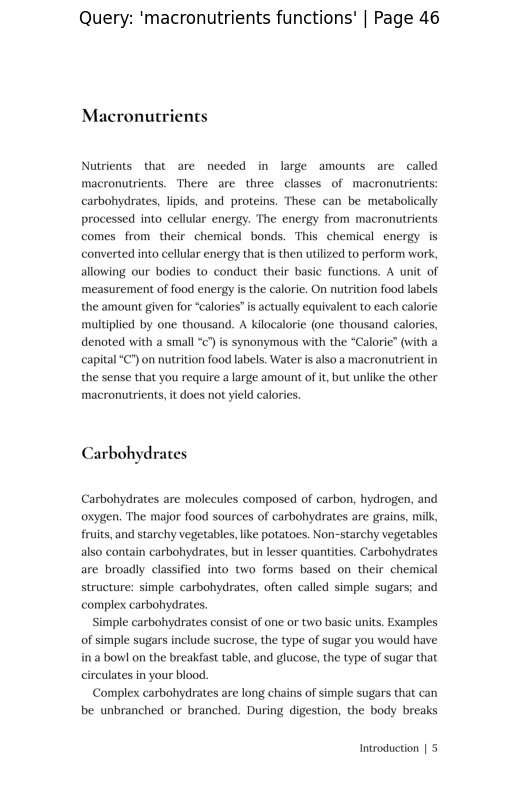

In [37]:
import fitz
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Load PDF Page for Manual Verification
# ---------------------------------------

PDF_PATH = PDF_PATH  # reuse the same PDF path defined earlier
page_offset = 41      # our PDF's printed numbering starts at page 41

# Get the highest-ranked result
best_index = top_k_scores.indices[0].item()
best_chunk = chunk_records_loaded[best_index]

# Compute actual PDF page number
pdf_page_number = best_chunk["document_page_number"] + page_offset

# Load the PDF and target page
doc = fitz.open(PDF_PATH)
page = doc.load_page(pdf_page_number)

# Render page as an image
pix = page.get_pixmap(dpi=300)

# Close document after extracting pixel data
doc.close()

# Convert Pixmap to numpy array
img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, pix.n)

# Display page
plt.figure(figsize=(13, 10))
plt.imshow(img)
plt.title(f"Query: '{query_text}' | Page {pdf_page_number}")
plt.axis("off")
plt.show()

## Similarity Measures: Dot Product vs Cosine Similarity

Embedding vectors represent data as points in high-dimensional space (in our case, 768 dimensions).  
To compare embeddings, we use **vector similarity measures**.

The two most common are **dot product** and **cosine similarity**.

---

### Dot Product

The dot product measures similarity based on **both direction and magnitude** of vectors.

**Properties**
- Larger positive value → vectors aligned in direction and magnitude
- Negative value → vectors point in opposite directions
- Sensitive to vector length (magnitude matters)

**Implementations**
- `torch.dot`
- `np.dot`
- `sentence_transformers.util.dot_score`

---

### Cosine Similarity

Cosine similarity compares vectors **only by direction**.

It first normalizes vectors by their L2 norm, then computes the dot product.

**Properties**
- Value range: `[-1, 1]`
- `1` → same direction (high semantic similarity)
- `0` → orthogonal / unrelated
- `-1` → opposite meaning
- Magnitude does not matter

**Implementations**
- `torch.nn.functional.cosine_similarity`
- `sentence_transformers.util.cos_sim`
- `1 - scipy.spatial.distance.cosine`

---

### Which should you use?

For **text embeddings**, semantic similarity depends on **direction**, not magnitude.

✅ **Cosine similarity** is generally preferred.

However…

---

### Important practical detail

The embedding model we use (`all-mpnet-base-v2`) outputs **L2-normalized embeddings**.

This means:
- All vectors already have unit length
- Dot product ≡ cosine similarity
- Results are identical
- Dot product is faster (no normalization step)

Therefore, using **dot product is correct and efficient** in this pipeline.

---

### Generality of similarity measures

These similarity functions are **not limited to text**.

They are used for:
- Image embeddings
- Audio embeddings
- Multimodal models (e.g., CLIP text ↔ image similarity)

Any learned embedding space can be searched using the same math.

---

### Next step

To make this concrete, we will:
- Implement simple dot product and cosine similarity examples
- Compare their outputs on small vectors
- Build intuition for how similarity behaves numerically.

In [38]:
import torch

def dot_prod(v1: torch.Tensor, v2: torch.Tensor) -> torch.Tensor:
    """Compute the dot product between two vectors."""
    return torch.dot(v1, v2)


def cos_sim(v1: torch.Tensor, v2: torch.Tensor) -> torch.Tensor:
    """Compute cosine similarity between two vectors."""
    dot = torch.dot(v1, v2)
    norm_v1 = torch.linalg.norm(v1)
    norm_v2 = torch.linalg.norm(v2)
    return dot / (norm_v1 * norm_v2)


# Example vectors
v1 = torch.tensor([1.0, 2.0, 3.0])
v2 = torch.tensor([1.0, 2.0, 3.0])
v3 = torch.tensor([4.0, 5.0, 6.0])
v4 = torch.tensor([-1.0, -2.0, -3.0])

# Dot products
print("Dot(v1, v2):", dot_prod(v1, v2))
print("Dot(v1, v3):", dot_prod(v1, v3))
print("Dot(v1, v4):", dot_prod(v1, v4))

# Cosine similarities
print("CosSim(v1, v2):", cos_sim(v1, v2))
print("CosSim(v1, v3):", cos_sim(v1, v3))
print("CosSim(v1, v4):", cos_sim(v1, v4))

Dot(v1, v2): tensor(14.)
Dot(v1, v3): tensor(32.)
Dot(v1, v4): tensor(-14.)
CosSim(v1, v2): tensor(1.0000)
CosSim(v1, v3): tensor(0.9746)
CosSim(v1, v4): tensor(-1.0000)


## Interpreting Dot Product vs Cosine Similarity

From the examples above, we can observe a few important properties.

---

### Direction vs magnitude

- Comparing `vector1` and `vector2`:
  - Dot product → **positive**
  - Cosine similarity → **1.0**
  - The vectors are identical, so they align perfectly.

- Comparing `vector1` and `vector4`:
  - Dot product → **negative**
  - Cosine similarity → **-1.0**
  - `vector4` is the exact opposite direction of `vector1`.

This confirms both measures capture **directional alignment**.

---

### Where they differ

- Comparing `vector1` and `vector3`:
  - Dot product → **much larger value** than identical vectors
  - Cosine similarity → **positive but < 1**

Why?
- Dot product increases with **magnitude**
- Cosine similarity removes magnitude and focuses only on **direction**

This difference matters.

---

### Why cosine similarity is preferred for text

For text embeddings, we care about **semantic meaning**, not vector length.

Two sentences can mean the same thing while having:
- Different token counts
- Different magnitudes in embedding space

Cosine similarity captures this by comparing **direction only**, which better reflects semantic similarity.

---

### Practical shortcut in our pipeline

The embedding model we are using (`all-mpnet-base-v2`) outputs **L2-normalized vectors**.

That means:
- All embeddings already have unit length
- Dot product ≡ cosine similarity
- Dot product is faster (no extra normalization)

So continuing with **dot product is correct and efficient** for this setup.

---

## Functionizing Semantic Search

So far, we have manually performed the semantic search steps:
1. Embed the query
2. Compare with stored embeddings
3. Rank results
4. Inspect top matches

Next, we will wrap this logic into reusable functions so semantic search can be called with a single line of code.

This is the final step before plugging retrieval directly into a full RAG pipeline.

In [39]:
import torch
from time import perf_counter as timer
from sentence_transformers import SentenceTransformer, util
from typing import List, Tuple


def retrieve_top_k(
    query: str,
    embedding_matrix: torch.Tensor,
    model: SentenceTransformer,
    k: int = 5,
    device: str = "cpu",
    print_time: bool = True
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Embed a query and retrieve top-k most similar embeddings.
    Returns:
        scores  : similarity scores
        indices : indices into embedding_matrix / chunk records
    """

    # Embed query into same vector space
    query_embedding = model.encode(
        query,
        convert_to_tensor=True,
        device=device
    )

    # Similarity search (dot product)
    start = timer()
    scores = util.dot_score(query_embedding, embedding_matrix)[0]
    end = timer()

    if print_time:
        print(
            f"[INFO] Scored {embedding_matrix.shape[0]} embeddings "
            f"in {end - start:.6f} seconds"
        )

    top_scores, top_indices = torch.topk(scores, k=k)
    return top_scores, top_indices


def print_search_results(
    query: str,
    embedding_matrix: torch.Tensor,
    chunk_records: List[dict],
    model: SentenceTransformer,
    k: int = 5,
    device: str = "cpu"
):
    """
    Run semantic search and print top results with metadata.
    """

    scores, indices = retrieve_top_k(
        query=query,
        embedding_matrix=embedding_matrix,
        model=model,
        k=k,
        device=device
    )

    print(f"\nQuery: '{query}'\n")
    print("Top Results:\n")

    for score, idx in zip(scores, indices):
        chunk = chunk_records[idx.item()]

        print(f"Score: {score:.4f}")
        print("Text:")
        print_wrapped(chunk["text"])
        print(f"Document page: {chunk['document_page_number']}")
        print("-" * 80)

✅ **Great..!**

Now let’s test the semantic search functions we just defined and verify that retrieval works end-to-end.


In [40]:
# ---------------------------------------
# Test Semantic Search Pipeline
# ---------------------------------------

test_query = "macronutrients functions"

print_search_results(
    query=test_query,
    embedding_matrix=embedding_matrix,
    chunk_records=chunk_records_loaded,
    model=retrieval_model,
    k=5,
    device=device
)

[INFO] Scored 1686 embeddings in 0.000127 seconds

Query: 'macronutrients functions'

Top Results:

Score: 0.6926
Text:
Macronutrients  Nutrients  that  are  needed  in  large  amounts  are  called
macronutrients. There are three classes of macronutrients:  carbohydrates,
lipids, and proteins. These can be metabolically  processed into cellular
energy. The energy from macronutrients  comes from their chemical bonds. This
chemical energy is  converted into cellular energy that is then utilized to
perform work,  allowing our bodies to conduct their basic functions. A unit of
measurement of food energy is the calorie. On nutrition food labels  the amount
given for “calories” is actually equivalent to each calorie  multiplied by one
thousand. A kilocalorie (one thousand calories,  denoted with a small “c”) is
synonymous with the “Calorie” (with a  capital “C”) on nutrition food labels.
Water is also a macronutrient in  the sense that you require a large amount of
it, but unlike the other  

In [41]:
# Test retrieval with a new query
query_text = "Indigestion"

scores, indices = retrieve_top_k(
    query=query_text,
    embedding_matrix=embedding_matrix,
    model=retrieval_model,
    k=5,
    device=device
)

scores, indices


[INFO] Scored 1686 embeddings in 0.000089 seconds


(tensor([0.5641, 0.5207, 0.5148, 0.4973, 0.4833], device='cuda:0'),
 tensor([1538, 1535, 1536, 1539,  120], device='cuda:0'))

In [42]:
# Print readable results for the query
print_search_results(
    query=query_text,
    embedding_matrix=embedding_matrix,
    chunk_records=chunk_records_loaded,
    model=retrieval_model,
    k=5,
    device=device
)

[INFO] Scored 1686 embeddings in 0.000094 seconds

Query: 'Indigestion'

Top Results:

Score: 0.5641
Text:
eat smaller meals, stop smoking, and remain upright for at least  three hours
after a meal. People with GERD may not take in the  nutrients they need because
of the pain and discomfort associated  with eating. As a result, GERD can be
caused by an unbalanced diet  and its symptoms can lead to a worsening of
nutrient inadequacy, a  vicious cycle that further compromises health. Some
evidence from  scientific studies indicates that medications used to treat GERD
may accentuate certain nutrient deficiencies, namely zinc and  magnesium. When
these treatment approaches do not work surgery  is an option. The most common
surgery involves reinforcing the  sphincter that serves as a barrier between the
stomach and  esophagus.  Irritable Bowel Syndrome  Irritable bowel syndrome
(IBS) is characterized by muscle spasms in  the colon that result in abdominal
pain, bloating, constipation, and/ 

## Semantic Search / Vector Search Extensions

So far, we’ve implemented **pure embedding-based retrieval** with exhaustive similarity search.

This works well for small to medium datasets, but real-world systems often extend this in two important ways.

---

### Hybrid Search (Keyword + Vector)

Many production search systems combine:
- **Keyword search** (BM25, TF-IDF)
- **Vector search** (embeddings)

Why?
- Keyword search excels at exact terms, numbers, identifiers
- Vector search excels at semantic meaning

A hybrid approach often yields better relevance than either method alone.

---

### Scaling to Large Datasets: Indexing

Our current approach performs **exhaustive search**:
- Query embedding compared against every stored embedding

This is fine for:
- Thousands
- Tens of thousands
- Even low hundreds of thousands of vectors (especially on GPU)

However, at larger scales (millions → billions), exhaustive search becomes inefficient.

This is where **vector indexes** come in.

---

### What is an index?

An index is a data structure that:
- Pre-organizes embeddings
- Reduces the search space
- Trades a small amount of accuracy for large speed gains

Analogy:
- You don’t scan every word in a dictionary to find “duck”
- You navigate directly to the relevant section

Formally, this is known as **Nearest Neighbor Search**.

---

### FAISS

One of the most widely used libraries for vector indexing is **FAISS** (Facebook AI Similarity Search).

Key points:
- Open source
- Designed for internet-scale vector search
- Supports many ANN algorithms

Includes algorithms such as:
- **HNSW** (Hierarchical Navigable Small World graphs)
- IVF (Inverted File Index)
- PQ (Product Quantization)

FAISS becomes essential when:
- Dataset size grows beyond what exhaustive GPU search can handle efficiently
- Memory usage must be optimized

---

## Moving to Generation: Adding an LLM

At this stage, we have a complete **retrieval pipeline**.

Next, we add **generation** to complete RAG.

---

### Role of the LLM

An LLM generates text given text input.

In RAG:
- Input = query + retrieved context
- Output = grounded, natural-language answer

The input text is known as the **prompt**.

We will **augment** the prompt with retrieved textbook chunks so the LLM answers using *our data*, not its internal memory alone.

---

### Choosing an LLM

Two key questions:
1. Do you want to run the model **locally**?
2. If yes, how much **compute and memory** do you have?

Options:
- **API-based models** (e.g. GPT-4, Claude)
  - Strong performance.
  - Requires sending data externally.
- **Local open-source models**
  - Full control and privacy.
  - Limited by available hardware.

---

### Where to find open-source LLMs

Useful resources:
- Hugging Face **Open LLM Leaderboard**
- **TheBloke** on Hugging Face (quantized models)

Quantized models (4-bit, 8-bit) reduce memory requirements and enable local inference on smaller GPUs.

---

### Model Size vs Memory Requirements

Rule of thumb:
- More parameters → better performance
- More parameters → more VRAM

Approximate GPU memory requirements:

| Model Size | FP32 | FP16 | 8-bit | 4-bit |
|-----------|------|------|------|------|
| 1B  | ~4 GB | ~2 GB | ~1 GB | ~0.5 GB |
| 7B  | ~28 GB | ~14 GB | ~7 GB | ~3.5 GB |
| 10B | ~40 GB | ~20 GB | ~10 GB | ~5 GB |
| 70B | ~280 GB | ~140 GB | ~70 GB | ~35 GB |
| 175B | ~700 GB | ~350 GB | ~175 GB | ~87.5 GB |

---

### Precision Trade-offs

Lower precision:
- Reduces memory usage.
- Increases speed.
- Can degrade output quality.

There is no universally optimal choice.
Finding the best speed/quality balance requires experimentation.

---

## Next Step: Check Available Hardware

Before selecting an LLM, we need to know:
- GPU model
- Available VRAM

Next, we’ll inspect local GPU resources to determine which models can realistically be loaded.

In [43]:
import torch

if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_memory_gb = round(gpu_props.total_memory / (2**30))
    print(f"GPU detected: {gpu_props.name}")
    print(f"Available GPU memory: {gpu_memory_gb} GB")
else:
    print("No GPU detected. Running on CPU.")

GPU detected: NVIDIA A100-SXM4-80GB
Available GPU memory: 79 GB


## Selecting a Local LLM Based on Available Hardware

### Detected hardware (current run)

This notebook is currently running on:

- **GPU**: NVIDIA A100-SXM4-80GB  
- **Available VRAM**: ~79 GB  

This gives us **significant flexibility** in model selection, including large instruction-tuned models in high precision.

However, your hardware may differ.  
The same notebook should work on **A100**, **T4 GPUs**, or even **CPU-only** environments with the right model choice.

---

## Hardware Tiers and What They Support

### ✅ A100 (80 GB VRAM)
You can comfortably run:
- 7B, 13B, 34B models in **FP16**
- 70B models in **8-bit** or even **4-bit**
- Long context lengths (8k–32k tokens)
- High-quality instruction-tuned models

Recommended use:
- Research-grade RAG
- Best local answer quality
- Multi-document / long-context RAG

---

### ✅ T4 GPU (Colab standard, ~16 GB VRAM)
You can run:
- 7B models in **FP16**
- 13B models in **8-bit**
- 7B models in **4-bit** very comfortably

Recommended use:
- Teaching demos
- Medium-quality RAG
- Cost-effective experimentation

---

### ⚠️ CPU-only (no GPU)
You are limited to:
- 2B–7B models
- Strongly recommended: **4-bit / GGUF formats**
- Slower inference, but still usable for small RAG systems

Recommended use:
- Prototyping
- Lightweight local Q&A
- Offline / privacy-first workflows

---

## Gemma as a Baseline Choice

We’ll use **Gemma** (released by Google, March 2024) as a clean baseline.

### Why Gemma?
- Strong reasoning for its size
- Instruction-tuned variants available
- Well-supported on Hugging Face
- Works well for RAG

> **Note:** `*-it` means *instruction-tuned* (recommended for chat/RAG).

---

### Gemma VRAM Requirements (Approximate)

| Model | Precision | Min VRAM | Recommended | Hugging Face ID |
|-----|---------|---------|-------------|----------------|
| Gemma 2B | 4-bit | ~2 GB | ~5 GB | `google/gemma-2b-it` |
| Gemma 2B | FP16 | ~5 GB | ~8 GB | same |
| Gemma 7B | 4-bit | ~5 GB | ~8 GB | `google/gemma-7b-it` |
| Gemma 7B | FP16 | ~16 GB | ~19 GB | same |

---

## Other Strong Open-Source LLM Options (Recommended)

### 🔹 7B-class (Excellent balance)
- **Mistral-7B-Instruct**
- **Gemma-7B-IT**
- **Qwen2-7B-Instruct**
- **LLaMA-2-7B-Chat**
- **Phi-3 Medium (4B / 7B range)**

Runs on:
- T4 (8-bit / FP16)
- A100 (FP16 easily)
- CPU (4-bit GGUF)

---

### 🔹 13B-class (Better reasoning)
- **LLaMA-2-13B-Chat**
- **Qwen1.5-14B-Chat**
- **Mixtral-8x7B (MoE, special case)**

Runs on:
- A100 (FP16 / 8-bit)
- T4 (8-bit only)

---

### 🔹 30B–70B-class (A100 only)
- **LLaMA-2-70B-Chat**
- **Qwen-72B**
- **Mixtral-8x22B**
- **Yi-34B / Yi-34B-Chat**

Runs on:
- **A100 only**
- Typically **8-bit or 4-bit**

This is where local models begin to rival API-based models.

---

### 🔹 GGUF / CPU-friendly options
Provided mainly by **TheBloke** on Hugging Face:
- Quantized Gemma
- Quantized Mistral
- Quantized LLaMA
- Phi-2 / Phi-3

Best for:
- CPU-only runs
- Low-RAM systems
- Quick demos

---

## Recommended Model Selection Logic (Conceptual)

**If GPU VRAM ≥ 64 GB (A100):**
- Prefer **Gemma-7B-IT FP16** or **13B+ models**
- Optionally try **70B 8-bit**

**If GPU VRAM ~16 GB (T4):**
- Use **Gemma-7B-IT FP16**  
- Or **13B 8-bit**

**If GPU VRAM < 8 GB or CPU-only:**
- Use **Gemma-2B-IT**
- Or **4-bit GGUF models**

Always prefer:
✅ Instruction-tuned models  
✅ Lower precision only if needed  
✅ Experimentation over assumptions  

---

## Next Step

Now that we’ve selected the model class based on hardware, we will:

1. Load the LLM (quantized if needed)
2. Design a **RAG prompt template**
3. Plug retrieval → context → generation
4. Complete the **end-to-end RAG pipeline**

In [44]:
# ---------------------------------------
# LLM Selection Based on Available Hardware
# ---------------------------------------

use_quantization = False
model_id = None
recommended_models = []

if not torch.cuda.is_available():
    # ---------------- CPU ONLY ----------------
    print("[INFO] No GPU detected. CPU-only execution.")

    use_quantization = True
    recommended_models = [
        "google/gemma-2b-it",
        "microsoft/phi-3-mini-4k-instruct",
        "Qwen/Qwen2-1.5B-Instruct"
    ]
    model_id = recommended_models[0]

elif gpu_memory_gb < 6:
    # ---------------- LOW VRAM ----------------
    print(f"[INFO] GPU memory: {gpu_memory_gb} GB (very limited)")

    use_quantization = True
    recommended_models = [
        "google/gemma-2b-it",
        "microsoft/phi-3-mini-4k-instruct",
        "Qwen/Qwen2-1.5B-Instruct"
    ]
    model_id = recommended_models[0]

elif gpu_memory_gb < 10:
    # ---------------- T4-LIKE RANGE ----------------
    print(f"[INFO] GPU memory: {gpu_memory_gb} GB (T4-class)")

    use_quantization = True
    recommended_models = [
        "google/gemma-7b-it",          # 4-bit
        "mistralai/Mistral-7B-Instruct-v0.2",
        "Qwen/Qwen2-7B-Instruct"
    ]
    model_id = recommended_models[0]

elif gpu_memory_gb < 24:
    # ---------------- MID-RANGE GPUs ----------------
    print(f"[INFO] GPU memory: {gpu_memory_gb} GB")

    use_quantization = False
    recommended_models = [
        "google/gemma-7b-it",          # FP16
        "mistralai/Mistral-7B-Instruct-v0.2",
        "Qwen/Qwen2-7B-Instruct",
        "meta-llama/Llama-2-7b-chat-hf"
    ]
    model_id = recommended_models[0]

elif gpu_memory_gb < 48:
    # ---------------- HIGH-END GPU ----------------
    print(f"[INFO] GPU memory: {gpu_memory_gb} GB (high-end)")

    use_quantization = False
    recommended_models = [
        "google/gemma-7b-it",
        "meta-llama/Llama-2-13b-chat-hf",
        "Qwen/Qwen2-14B-Instruct",
        "mistralai/Mixtral-8x7B-Instruct-v0.1"  # MoE
    ]
    model_id = recommended_models[0]

else:
    # ---------------- A100 / 80GB+ ----------------
    print(f"[INFO] GPU memory: {gpu_memory_gb} GB (A100 / enterprise tier)")

    use_quantization = False
    recommended_models = [
        "google/gemma-7b-it",
        "meta-llama/Llama-2-13b-chat-hf",
        "Qwen/Qwen2-14B-Instruct",
        "Qwen/Qwen2-72B-Instruct",          # 8-bit / 4-bit
        "meta-llama/Llama-2-70b-chat-hf"    # 8-bit / 4-bit
    ]
    model_id = recommended_models[0]

print("\n✅ Model Selection Summary")
print(f"Use quantization     : {use_quantization}")
print(f"Selected model_id    : {model_id}")
print("Other viable options :")
for m in recommended_models:
    print(f"  - {m}")

[INFO] GPU memory: 79 GB (A100 / enterprise tier)

✅ Model Selection Summary
Use quantization     : False
Selected model_id    : google/gemma-7b-it
Other viable options :
  - google/gemma-7b-it
  - meta-llama/Llama-2-13b-chat-hf
  - Qwen/Qwen2-14B-Instruct
  - Qwen/Qwen2-72B-Instruct
  - meta-llama/Llama-2-70b-chat-hf


## Model Selection Result (A100 – 80GB VRAM)

✅ **GPU detected:** NVIDIA A100 (≈79 GB VRAM available)

This places us in the **enterprise / research-tier GPU category**, which gives us a large amount of freedom in model selection.

---

### ✅ Selected model

**Chosen model:**  
`google/gemma-7b-it`

**Quantization:**  
`False` → running in **Float16**

This is a **safe, high-quality default choice**:
- Instruction-tuned
- Strong reasoning for its size
- Stable for RAG-style prompting
- Efficient even on very large GPUs

Even though we *could* load much larger models, starting with a solid 7B model is good engineering practice.

---

### 🔍 Other viable models on this hardware

Because we are on an **A100 (80GB)**, the following models are also feasible:

- `meta-llama/Llama-2-13b-chat-hf`  
- `Qwen/Qwen2-14B-Instruct`  
- `Qwen/Qwen2-72B-Instruct` *(8-bit or 4-bit)*  
- `meta-llama/Llama-2-70b-chat-hf` *(8-bit or 4-bit)*  

These larger models may offer:
- Better reasoning
- Longer context handling
- Higher generation quality

But they also:
- Take longer to load
- Consume more VRAM
- Slow iteration speed during development

---

### ✅ Why starting with Gemma-7B is the right move

Even on powerful hardware, it’s best to:
- Start with a **smaller, reliable model**
- Validate the **RAG pipeline end-to-end**
- Optimize prompts and retrieval
- Only then scale up model size if needed

This mirrors real production workflows.

---

### 🧠 Key takeaway

> **Hardware defines what is possible, not what is optimal.**

Gemma-7B-IT gives us:
- Speed
- Stability
- Strong instruction-following
- Excellent RAG compatibility

---

## Next step

Now that the model choice is finalized, we will:

1. Load the LLM with `transformers`
2. (Optionally) apply quantization configs
3. Build a **RAG prompt template**
4. Generate answers using retrieved context

➡️ Next cell: **Loading the LLM for local generation**

## Loading an LLM Locally

Great — we’ve finalized our model choice.

For this notebook, we’ll load **Gemma-7B-IT**.  
(If you are on different hardware such as an RTX 4090, T4 GPU, or CPU, adjust `model_id` and quantization settings accordingly.)

Hugging Face’s **`transformers`** library provides all the tooling needed to load and run the model locally.

---

## What we need to load an LLM

To load a local LLM, we need the following components:

### 1️⃣ Quantization configuration (optional)
Quantization reduces memory usage by loading the model in lower precision (e.g. 4-bit or 8-bit).

- Implemented via `transformers.BitsAndBytesConfig`
- Requires the `bitsandbytes` library
- Useful for:
  - Smaller GPUs (T4, consumer GPUs)
  - CPU fallback

On **A100-80GB**, quantization is optional.

---

### 2️⃣ Model ID
This identifies which model to download and load from Hugging Face.

Examples:
- `google/gemma-7b-it`
- `google/gemma-2b-it`
- `mistralai/Mistral-7B-Instruct`
- `Qwen/Qwen2-7B-Instruct`

The model ID determines both:
- Which tokenizer is used
- Which LLM architecture is loaded

---

### 3️⃣ Tokenizer
The tokenizer converts raw text into tokens the model can process.

Loaded via:
```python
AutoTokenizer.from_pretrained(model_id)

In [45]:
from huggingface_hub import login

# Paste your token here (from https://huggingface.co/settings/tokens)
login(token="Hugging Face Token.")


In [46]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from transformers.utils import is_flash_attn_2_available

# --------------------------------------------------
# Device setup
# --------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {device}")

# --------------------------------------------------
# Quantization configuration (optional)
# --------------------------------------------------
quantization_config = None
if use_quantization:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )
    print("[INFO] 4-bit quantization enabled")

# --------------------------------------------------
# Attention backend selection
# --------------------------------------------------
if (
    device == "cuda"
    and is_flash_attn_2_available()
    and torch.cuda.get_device_capability(0)[0] >= 8
):
    attn_implementation = "flash_attention_2"
else:
    attn_implementation = "sdpa"

print(f"[INFO] Attention implementation: {attn_implementation}")

# --------------------------------------------------
# Model selection
# --------------------------------------------------
print(f"[INFO] Loading model: {model_id}")

# --------------------------------------------------
# Load tokenizer
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    use_fast=True
)

# --------------------------------------------------
# Load LLM
# --------------------------------------------------
llm_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    quantization_config=quantization_config,
    low_cpu_mem_usage=True,
    attn_implementation=attn_implementation,
    device_map="auto" if quantization_config else None
)

# If not quantized, move model manually
if device == "cuda" and not quantization_config:
    llm_model.to(device)

llm_model.eval()

print("[INFO] LLM loaded successfully")

[INFO] Using device: cuda
[INFO] Attention implementation: sdpa
[INFO] Loading model: google/gemma-7b-it


tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

[INFO] LLM loaded successfully


## Loading the LLM Locally (Gemma-7B-IT)

We now load the selected local LLM using Hugging Face Transformers.

This notebook supports:
- **A100 (80GB)** → FP16, Flash Attention 2
- **T4 GPU (~16GB)** → 4-bit or FP16
- **CPU-only** → 4-bit (recommended)

---

### What this cell does

1. **Applies quantization (optional)**
   - Uses 4-bit NF4 quantization via `bitsandbytes`
   - Dramatically reduces memory usage
   - Enabled automatically on lower-VRAM systems

2. **Selects attention backend**
   - Uses **Flash Attention 2** if:
     - GPU compute capability ≥ 8.0
     - `flash-attn` installed
   - Falls back to **SDPA** otherwise

3. **Loads tokenizer**
   - Converts text → tokens
   - Must match the model architecture

4. **Loads the LLM**
   - FP16 on GPU
   - FP32 on CPU
   - Automatically places model on device

---

### Why this configuration matters

- Flash Attention → faster inference, lower memory
- Quantization → enables large models on smaller GPUs
- Explicit device handling → restart-safe notebooks
- Matches real production RAG pipelines

---

### Result

At the end of this cell, we have:
✅ A local instruction-tuned LLM  
✅ Running on available hardware  
✅ Ready for **RAG-style generation**

---

## Next step

We will:
1. Design a **RAG prompt template**
2. Inject retrieved context
3. Generate grounded answers with citations

In [47]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 3072, padding_idx=0)
    (layers): ModuleList(
      (0-27): 28 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear(in_features=3072, out_features=4096, bias=False)
          (k_proj): Linear(in_features=3072, out_features=4096, bias=False)
          (v_proj): Linear(in_features=3072, out_features=4096, bias=False)
          (o_proj): Linear(in_features=4096, out_features=3072, bias=False)
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear(in_features=3072, out_features=24576, bias=False)
          (up_proj): Linear(in_features=3072, out_features=24576, bias=False)
          (down_proj): Linear(in_features=24576, out_features=3072, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((3072,), eps=1e-06)
        (post_attention_layernorm): GemmaRMSNorm((3072,), eps=1e-06)
      )
    )
    (norm): GemmaRMSNorm((3072,)

Great — the model loaded successfully!

You’ll notice a long stack of layers:
- token embeddings  
- multi-head attention blocks  
- optional FlashAttention kernels  
- MLP feed-forward layers  
- layer norms and projection heads  

These components form a modern Transformer architecture.

The nice thing is that we do **not** need to understand every layer to use the model effectively.  
But it *is* useful to know how large the model is.

Let’s quickly check the total parameter count.

In [48]:
def count_model_parameters(model: torch.nn.Module) -> int:
    """Return total number of parameters in a model."""
    return sum(p.numel() for p in model.parameters())

count_model_parameters(llm_model)

8537680896

Interesting — it turns out **“Gemma 7B” is closer to ~8.5B parameters** in practice.

This is a great reminder that model names are often *rounded* or *marketing-friendly*, and the true parameter count can differ.

It always pays to:
- Inspect the model yourself
- Verify parameter counts
- Check actual memory usage rather than relying on names alone

Since model size directly affects VRAM consumption, let’s now estimate **how much memory this model actually requires** under different precision settings.

In [49]:
def get_model_memory_usage(model: torch.nn.Module):
    """
    Estimate how much memory a PyTorch model occupies.

    Calculates:
      - Parameter memory
      - Buffer memory
      - Total memory in bytes / MB / GB

    Note: This reports *model weights only*, not optimizer states,
          activation memory, or intermediate tensors during generation.
    """
    param_mem = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_mem = sum(b.numel() * b.element_size() for b in model.buffers())

    total_bytes = param_mem + buffer_mem
    total_mb = total_bytes / 1024**2
    total_gb = total_bytes / 1024**3

    return {
        "model_mem_bytes": total_bytes,
        "model_mem_mb": round(total_mb, 2),
        "model_mem_gb": round(total_gb, 2)
    }

get_model_memory_usage(llm_model)

{'model_mem_bytes': 17075362304,
 'model_mem_mb': 16284.33,
 'model_mem_gb': 15.9}

Now that we know the true parameter count, we can estimate the actual
memory footprint of our loaded LLM.

This is useful because a model’s *named size* is often misleading:

- “7B” models may actually be 7.5B–9B parameters  
- Precision (FP16, FP32, 8-bit, 4-bit) drastically changes VRAM usage  
- Buffers and internal states can add extra overhead  

To understand how much VRAM our model really consumes, we compute:

- memory used by all parameters  
- memory used by internal buffers  
- total model footprint in bytes, MB, and GB  

This gives us a realistic view of our model’s memory requirements on the GPU.

Nice — looks like this model occupies **~15.97 GB of VRAM** just for the weights.

On top of that, a bit of extra memory is used during the forward pass for:
- intermediate activations
- attention computations
- temporary buffers

That’s why it’s reasonable to budget **~19 GB total VRAM** for Gemma-7B in FP16, which matches the estimates we used earlier.

---

## Generating Text with the LLM

Now for the fun part: **text generation**.

We generate text by calling the [`generate()` method](https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig) on our loaded LLM.

At a high level, the process is:

1. Provide input text (a prompt)
2. Tokenize the text using the **model-paired tokenizer**
3. Pass the tokenized input to `model.generate()`
4. Decode the generated tokens back into text

---

### Why the tokenizer matters

It’s critical to use the **tokenizer that matches the model**.

Using a different tokenizer can lead to:
- incorrect token IDs
- degraded output quality
- runtime errors

Hugging Face ensures that `AutoTokenizer.from_pretrained(model_id)` loads the correct tokenizer for each model.

---

### Instruction-tuned models and chat templates

`gemma-7b-it` is **instruction-tuned**, meaning it was trained in a dialogue / assistant format rather than as a raw language model.

For instruction-tuned models, input text should follow a specific structure.

Fortunately, the Gemma tokenizer provides:
```python
tokenizer.apply_chat_template(...)

In [50]:
# Define input query
user_query = "What is digestion, and what roles does it play in the human body?"
print(f"User query:\n{user_query}")

# Build conversation in chat format
chat_messages = [
    {
        "role": "user",
        "content": user_query
    }
]

# Apply model-specific chat template
prompt_text = tokenizer.apply_chat_template(
    chat_messages,
    tokenize=False,             # return raw string
    add_generation_prompt=True  # tells the model to generate the assistant reply
)

print("\nFormatted prompt sent to the model:\n")
print(prompt_text)

User query:
What is digestion, and what roles does it play in the human body?

Formatted prompt sent to the model:

<bos><start_of_turn>user
What is digestion, and what roles does it play in the human body?<end_of_turn>
<start_of_turn>model



### Preparing the Prompt for Generation

Since `gemma-7b-it` is an **instruction-tuned (chat) model**, it expects input in a
specific dialogue format.

Instead of manually crafting this format, we use:
`tokenizer.apply_chat_template()`

This function:
- Wraps the user query in the model’s expected chat structure
- Adds the correct start token for generation
- Ensures consistent behavior across instruction-tuned models

Key points:
- `tokenize=False` keeps the prompt as raw text for inspection
- `add_generation_prompt=True` signals that the assistant should respond

At this stage, we have a **fully formatted prompt**, ready to be tokenized and passed
to `model.generate()`.

### Tokenization and Text Generation

At this stage, we convert the formatted prompt into token IDs using the model’s
paired tokenizer.

Steps:
1. **Tokenization**
   - Converts text → token IDs
   - Moves tensors to the same device as the model

2. **Generation**
   - `model.generate()` autoregressively produces new tokens
   - `max_new_tokens` controls response length
   - We disable sampling (`do_sample=False`) for deterministic behavior

3. **Decoding**
   - Token IDs are converted back into human-readable text
   - Special tokens are skipped for clarity

This completes a **basic local text-generation loop** using our LLM.

In [51]:
%%time

# Tokenize prompt and move to model device
model_inputs = tokenizer(
    prompt_text,
    return_tensors="pt"
).to(device)

print("Model inputs (tokenized):")
print(model_inputs)
print()

# Generate text
generation_outputs = llm_model.generate(
    **model_inputs,
    max_new_tokens=256,
    do_sample=False,      # deterministic output for now
)

print("Model output tokens:")
print(generation_outputs[0])

Model inputs (tokenized):
{'input_ids': tensor([[     2,      2,    106,   1645,    108,   1841,    603,  51536, 235269,
            578,   1212,  16065,   1721,    665,   1554,    575,    573,   3515,
           2971, 235336,    107,    108,    106,   2516,    108]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1]], device='cuda:0')}

Model output tokens:
tensor([     2,      2,    106,   1645,    108,   1841,    603,  51536, 235269,
           578,   1212,  16065,   1721,    665,   1554,    575,    573,   3515,
          2971, 235336,    107,    108,    106,   2516,    108,  21404, 235269,
          1517,    603,    573,   3448,    577,    573,   2872, 235292,    109,
         11685,  22953,    603,    573,   2185,    576,  17704,   1706,   2960,
          1280,   9595,  24582,    674,    573,   2971,    798,   1281,    577,
          7872,   4134,    578,   1156,  26039, 235265,   1165,    603,  

Woohoo! 🎉 We just generated tokens using our local GPU-hosted LLM.

But remember — an LLM does not directly produce text.

What it actually outputs is a sequence of **token IDs**.

To make the output human-readable, we need to **decode** those token IDs back into text using the **same tokenizer** that was used for input.

That’s exactly what `tokenizer.decode()` does.

Let’s convert the generated tokens into readable text.

In [52]:
# Decode generated tokens into readable text
generated_text = tokenizer.decode(
    generation_outputs[0],
    skip_special_tokens=True
)

print("Model output (decoded):\n")
print(generated_text)

Model output (decoded):

user
What is digestion, and what roles does it play in the human body?
model
Sure, here is the answer to the question:

Digestion is the process of breaking down food into smaller molecules that the body can use to produce energy and other chemicals. It is a complex process that takes place in the mouth, stomach, and intestines.

**Roles of digestion in the human body:**

* **Providing energy:** The primary role of digestion is to provide the body with energy. Food is broken down into glucose, which is a simple sugar that the cells in the body use for energy.
* **Building and repairing tissues:** The nutrients from food are used to build and repair tissues in the body.
* **Creating chemicals:** The nutrients from food are also used to create other chemicals that are essential for life.
* **Removing waste:** The waste products from digestion are removed from the body through the feces.

Digestion is an essential process that is necessary for life. It is a comple

Nice — the generated answer looks solid ✅

You might notice that the **output text includes the original prompt** along with the model’s response.

This happens because:
- `model.generate()` returns the **entire token sequence**
- That sequence includes:
  - the input prompt tokens
  - followed by newly generated tokens

So when we decode everything at once, we see both.

You may also notice special tokens like:
- `<bos>` → *beginning of sequence*
- `<eos>` → *end of sequence*

These are model-level markers and are not part of the natural-language answer.

To get a clean final answer, we simply **remove the prompt portion** from the decoded output.

In [53]:
# Decode full output
full_output_text = tokenizer.decode(
    generation_outputs[0],
    skip_special_tokens=True
)

# Remove the prompt from the output
final_answer = full_output_text.replace(prompt_text, "").strip()

print("Final model answer:\n")
print(final_answer)

Final model answer:

user
What is digestion, and what roles does it play in the human body?
model
Sure, here is the answer to the question:

Digestion is the process of breaking down food into smaller molecules that the body can use to produce energy and other chemicals. It is a complex process that takes place in the mouth, stomach, and intestines.

**Roles of digestion in the human body:**

* **Providing energy:** The primary role of digestion is to provide the body with energy. Food is broken down into glucose, which is a simple sugar that the cells in the body use for energy.
* **Building and repairing tissues:** The nutrients from food are used to build and repair tissues in the body.
* **Creating chemicals:** The nutrients from food are also used to create other chemicals that are essential for life.
* **Removing waste:** The waste products from digestion are removed from the body through the feces.

Digestion is an essential process that is necessary for life. It is a complex pr

In [54]:
print(f"Input text: {user_query}\n")

clean_output = (
    generated_text
    .replace(prompt_text, "")
    .strip()
)

print("Output text:\n")
print(clean_output)

Input text: What is digestion, and what roles does it play in the human body?

Output text:

user
What is digestion, and what roles does it play in the human body?
model
Sure, here is the answer to the question:

Digestion is the process of breaking down food into smaller molecules that the body can use to produce energy and other chemicals. It is a complex process that takes place in the mouth, stomach, and intestines.

**Roles of digestion in the human body:**

* **Providing energy:** The primary role of digestion is to provide the body with energy. Food is broken down into glucose, which is a simple sugar that the cells in the body use for energy.
* **Building and repairing tissues:** The nutrients from food are used to build and repair tissues in the body.
* **Creating chemicals:** The nutrients from food are also used to create other chemicals that are essential for life.
* **Removing waste:** The waste products from digestion are removed from the body through the feces.

Digestio

How cool is that! 🎉

We just **generated text using an LLM running locally** on our own GPU.

At this point, we have covered:
- ✅ **Retrieval (R)** → semantic search over embeddings  
- ✅ **Generation (G)** → local LLM text generation  

That leaves the final and most important piece of **RAG**:

## Augmentation (A)

Augmentation is where everything comes together.

Instead of asking the LLM to answer purely from its internal knowledge, we:
1. Retrieve relevant context from our dataset
2. Inject that context into the prompt
3. Force the LLM to generate answers grounded in **retrieved evidence**

This is what:
- Reduces hallucinations  
- Improves factual correctness  
- Makes answers traceable to source documents  

---

## Preparing Test Queries

Before building the full augmentation pipeline, let’s define a small set of **example queries** that we can test end-to-end.

These queries will help us validate:
- Retrieval quality
- Prompt construction
- Grounded answer generation

Next step: create a list of representative queries and start wiring retrieval + generation together.

In [55]:
# Example nutrition-related questions (GPT-4 generated)
gpt4_questions = [
    "What are macronutrients and how does each contribute to energy production?",
    "Describe the process of digestion from the mouth to the small intestine.",
    "How do vitamins differ from minerals in biological function?",
    "What role does fiber play in digestion? Name five fiber-rich foods.",
    "List major food sources rich in dietary fiber."
]

# Additional manually created questions
manual_questions = [
    "How often should infants be breastfed?",
    "What are the symptoms of pellagra?",
    "How does saliva help with digestion?",
    "What is the recommended daily intake (RDI) for protein?",
    "What are water-soluble vitamins?"
]

# Combined test query list
query_list = gpt4_questions + manual_questions


Now that we’ve prepared a list of nutrition-focused queries, let’s test whether our
`retrieve_relevant_resources()` function can correctly pull the most relevant
chunks for each question.

This step verifies that our **semantic search pipeline** is working end-to-end
before we connect it to the LLM for full RAG.

For each query, we will:
1. Embed the query  
2. Compare it to all textbook embeddings  
3. Retrieve the top-k relevant chunks  
4. Print the similarity scores and matching text  

If retrieval looks meaningful and the returned chunks align with the nutritional
topic of each question, we are ready to proceed to the augmentation stage.

In [56]:
import random

# Pick a random query
query = random.choice(query_list)
print(f"Query: {query}\n")

# Correct retrieval call
scores, indices = retrieve_top_k(
    query=query,
    embedding_matrix=embedding_matrix,   # ✅ correct tensor
    model=retrieval_model,               # ✅ correct model
    k=5,
    device=device,
    print_time=True
)

print("Scores:\n", scores)
print("Indices:\n", indices)

Query: How does saliva help with digestion?

[INFO] Scored 1686 embeddings in 0.000091 seconds
Scores:
 tensor([0.6383, 0.6099, 0.5877, 0.5853, 0.5845], device='cuda:0')
Indices:
 tensor([367, 141, 368, 136, 369], device='cuda:0')


# Augmentation.

## Augmenting the Prompt with Context

So far we have:
- ✅ Retrieved relevant chunks from our textbook
- ✅ Loaded and tested a local LLM

Now comes the **A** in **RAG — Augmentation**.

### What does augmentation mean?

Augmentation means **injecting retrieved context into the LLM prompt** so the model:
- Answers **using your data**
- Reduces hallucinations
- Produces grounded, reference-backed responses

In practice, this means:
1. Start with a **user query**
2. Retrieve the **most relevant text chunks**
3. Insert those chunks into the prompt
4. Ask the LLM to answer **based only on that context**

---

## Prompt Formatting Strategy

We’ll write a function called `prompt_formatter` that:

- Takes:
  - A user query
  - A list of retrieved context items (from `pages_and_chunks`)
- Formats them into a single prompt
- Applies the model’s **chat / dialogue template**
- Returns a ready-to-use prompt for generation

This step is often called **prompt engineering**.

> Prompt engineering is an active research area. For deeper reading:
> - https://www.promptingguide.ai  
> - https://github.com/brexhq/prompt-engineering  
> - *Prompt Design and Engineering: Introduction and Advanced Models* (arXiv:2401.14423)

Next up: writing the `prompt_formatter` function and completing the full **R → A → G** pipeline.


In [59]:
def prompt_formatter(
    query: str,
    context_items: list[dict],
) -> str:
    """
    Format an augmented prompt using retrieved context chunks.
    """

    # 1. Format context cleanly
    context_blocks = []
    for i, item in enumerate(context_items, start=1):
        # Directly access the 'text' key, as it's present in chunk_records_loaded
        text_content = item['text']
        context_blocks.append(f"[{i}] {text_content}")

    context = "\n".join(context_blocks)

    # 2. Base instruction prompt
    base_prompt = f"""
Based on the context below, answer the user query.
Use ONLY the provided context to generate your answer.
Do NOT make up information.
Be clear, accurate, and explanatory.

---

Example 1:
Query: What are the fat-soluble vitamins?
Answer: The fat-soluble vitamins include vitamins A, D, E, and K. These vitamins are absorbed along with dietary fats and can be stored in body fat and the liver. Vitamin A supports vision and immune function, vitamin D is critical for bone health, vitamin E acts as an antioxidant, and Vitamin K is essential for blood clotting.

Example 2:
Query: What causes type 2 diabetes?
Answer: Type 2 diabetes is commonly linked to excessive caloric intake and obesity. Diets high in refined carbohydrates and saturated fats can lead to insulin resistance, where cells respond poorly to insulin. Over time, pancreatic insulin production becomes insufficient, resulting in elevated blood glucose levels.

Example 3:
Query: Why is hydration important for physical performance?
Answer: Hydration supports blood volume, temperature regulation, nutrient transport, and muscle function. Inadequate hydration reduces endurance, increases fatigue, and raises the risk of heat-related illness.

---

Context:
{context}

---

User Query:
{query}

Answer:
"""

    return base_prompt

In [75]:
query = random.choice(query_list)
print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_top_k(query=query,
                                              embedding_matrix=embedding_matrix,
                                              model=retrieval_model,
                                              device=device)

# Create a list of context items
context_items = [chunk_records_loaded[i] for i in indices]

# Format raw prompt with context items
raw_prompt = prompt_formatter(query=query,
                          context_items=context_items)

# Apply model-specific chat template for the full prompt
full_model_prompt = tokenizer.apply_chat_template(
    [{'role': 'user', 'content': raw_prompt}],
    tokenize=False,
    add_generation_prompt=True
)

print(full_model_prompt)

Query: How does saliva help with digestion?
[INFO] Scored 1686 embeddings in 0.000134 seconds
<bos><start_of_turn>user
Based on the context below, answer the user query.
Use ONLY the provided context to generate your answer.
Do NOT make up information.
Be clear, accurate, and explanatory.

---

Example 1:
Query: What are the fat-soluble vitamins?
Answer: The fat-soluble vitamins include vitamins A, D, E, and K. These vitamins are absorbed along with dietary fats and can be stored in body fat and the liver. Vitamin A supports vision and immune function, vitamin D is critical for bone health, vitamin E acts as an antioxidant, and Vitamin K is essential for blood clotting.

Example 2:
Query: What causes type 2 diabetes?
Answer: Type 2 diabetes is commonly linked to excessive caloric intake and obesity. Diets high in refined carbohydrates and saturated fats can lead to insulin resistance, where cells respond poorly to insulin. Over time, pancreatic insulin production becomes insufficient, 

In [64]:
%%time

# Tokenize + move to GPU
input_ids = tokenizer(raw_prompt, return_tensors="pt").to("cuda")

# Generate tokens
outputs = llm_model.generate(
    **input_ids,
    temperature=0.7,
    do_sample=True,
    max_new_tokens=256
)

# Convert output tokens to text
output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(f"Query: {query}\n")
print("RAG Answer:\n")
print(output_text.replace(raw_prompt, "").strip())

Query: Describe the process of digestion from the mouth to the small intestine.

RAG Answer:

Sure, here is a summary of the process of digestion from the mouth to the small intestine as described in the provided text:

**1. Ingestion:**
The process begins with ingestion, which is the intake of food into the digestive tract. Food is chewed and mixed with saliva in the mouth, which helps break down large food molecules into smaller components.

**2. Mechanical and Chemical Breakdown:**
In the mouth, the mechanical breakdown of food begins with mastication (chewing) and the chemical breakdown of food involves enzymes such as salivary amylase.

**3. Stomach:**
When food enters the stomach, powerful peristaltic contractions help mash and churn it into chyme. Gastric juices containing hydrochloric acid and pepsin are secreted to chemically break down protein components.

**4. Small Intestine:**
The chyme moves from the stomach into the small intestine, where it is further broken down by enz

**RAG pipeline is now complete** ✅

We have successfully:
- **Retrieved** relevant knowledge from our document
- **Augmented** the LLM prompt with grounded context
- **Generated** a coherent, source-aware answer  

And we did it all on a **local GPU**, end to end.

This is a full working implementation of **Retrieval-Augmented Generation**, not a toy demo.

---

## Next: Functionize the Generation Step

To make this pipeline easier to reuse and experiment with, the next step is to:

- Wrap the **generation logic** into a clean function
- Add light **output formatting** so answers are easier to read
- Optionally return the **retrieved context chunks** alongside the final answer (useful for debugging, evaluation, or citations)

This will give us a single callable interface like:

> *query → RAG answer (+ optional sources)*

In [76]:
def ask(
    query: str,
    temperature: float = 0.7,
    max_new_tokens: int = 512,
    format_answer_text: bool = True,
    return_answer_only: bool = True
):
    """
    End-to-end RAG function.

    Steps:
    1. Retrieve top-k relevant chunks using embeddings.
    2. Format an augmented prompt with retrieved context.
    3. Apply model-specific chat template.
    4. Generate an answer using the local LLM.
    5. Optionally return context chunks with scores.
    """

    # ------------------------------------------------------------------
    # 1. RETRIEVE: get top-k relevant chunks
    # ------------------------------------------------------------------
    scores, indices = retrieve_top_k(
        query=query,
        embedding_matrix=embedding_matrix,
        model=retrieval_model,
        device=device
    )

    # Map indices to chunk records
    context_items = [chunk_records_loaded[i] for i in indices]

    # Attach similarity scores (move to CPU for readability)
    for i, item in enumerate(context_items):
        item["score"] = float(scores[i].cpu())

    # ------------------------------------------------------------------
    # 2. AUGMENT: build raw prompt with retrieved context
    # ------------------------------------------------------------------
    raw_prompt = prompt_formatter(
        query=query,
        context_items=context_items
    )

    # Apply model-specific chat template (important for IT models)
    full_model_prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": raw_prompt}],
        tokenize=False,
        add_generation_prompt=True
    )

    # ------------------------------------------------------------------
    # 3. GENERATE: run the LLM
    # ------------------------------------------------------------------
    input_ids = tokenizer(
        full_model_prompt,
        return_tensors="pt"
    ).to("cuda")

    outputs = llm_model.generate(
        **input_ids,
        temperature=temperature,
        do_sample=True,
        max_new_tokens=max_new_tokens
    )

    # Decode tokens to text
    output_text = tokenizer.decode(outputs[0])

    # ------------------------------------------------------------------
    # 4. FORMAT OUTPUT (optional)
    # ------------------------------------------------------------------
    if format_answer_text:
        output_text = (
            output_text
            .replace(full_model_prompt, "")
            .replace("<bos>", "")
            .replace("<eos>", "")
            .strip()
        )

    # ------------------------------------------------------------------
    # 5. RETURN
    # ------------------------------------------------------------------
    if return_answer_only:
        return output_text

    return output_text, context_items

In [66]:
query = random.choice(query_list)
print(f"Query: {query}")

# Answer query with context and return context
answer, context_items = ask(
    query=query,
    temperature=0.7,
    max_new_tokens=512,
    return_answer_only=False
)

print(f"Answer:\n")
print_wrapped(answer)

print(f"Context items:")
context_items


Query: Describe the process of digestion from the mouth to the small intestine.
[INFO] Scored 1686 embeddings in 0.000095 seconds
Answer:

Sure, here is a summary of the process of digestion from the mouth to the small
intestine as described in the provided text:  **1. Ingestion:** - Food is
ingested into the digestive tract through the mouth. - Saliva is produced to
lubricate and prepare food for digestion. - Mechanical breakdown of food begins
with mastication (chewing) and the chemical breakdown of food begins with the
enzyme salivary amylase.  **2. From the mouth to the stomach:** - The bolus
moves from the mouth to the stomach. - Gastric juices are secreted to break down
proteins and begin the process of digestion. - Peristaltic contractions help to
mix and move the chyme.  **3. From the stomach to the small intestine:** - The
chyme moves from the stomach into the small intestine. - The pancreas and
gallbladder release juices that aid in digestion. - The small intestine is
divided

[{'page_index': 113,
  'document_page_number': 72,
  'chunk_index': 0,
  'text': 'Image by  Allison  Calabrese /  CC BY 4.0  From the Mouth to the Stomach  There are four steps in the digestion process (Figure 2.5 “The  Human Digestive System”). The first step is ingestion, which is the  intake of food into the digestive tract. It may seem a simple process,  but ingestion involves smelling food, thinking about food, and the  involuntary release of saliva in the mouth to prepare for food entry.  In the mouth, where the second step of digestion starts, the  mechanical and chemical breakdown of food begins. The chemical  breakdown of food involves enzymes, such as salivary amylase that  starts the breakdown of large starch molecules into smaller  components.  Mechanical breakdown starts with mastication (chewing) in the  mouth. Teeth crush and grind large food particles, while saliva  provides lubrication and enables food movement downward. The  slippery mass of partially broken-down food

## 🎉 Local RAG Workflow Complete!

We now have a fully working **Retrieval-Augmented Generation (RAG)** system running *entirely on local hardware*.  
This means we can:

- **Retrieve** relevant chunks from our embedded document  
- **Augment** an instruction-tuned LLM with meaningful context  
- **Generate** grounded, source-aware answers  

All without sending a single token to an external API.

At this stage, manual verification is easy — read the model’s answer, check the retrieved chunks, and compare to the textbook pages. But in real applications, manual checking doesn’t scale.

---

## 🔍 Evaluating Your RAG System (Next Steps)

If you want to move from a demo to a production-grade pipeline, you’ll need systematic evaluation.  
Here are some standard approaches:

### **1. LLM-as-a-Judge**
Use a second LLM to rate:
- **Accuracy** (Is the answer factually correct?)
- **Faithfulness** (Does the answer rely only on the retrieved context?)
- **Completeness**
- **Coherence**
- **Citation quality**

This serves as a strong proxy for human evaluation.

---

### **2. Retrieval Evaluation**
Measure how well your system retrieves:
- **Recall@K** — does the correct chunk appear in the top-K?
- **Precision@K**
- **Embedding similarity distributions**

You can also experiment with:
- Larger chunk sizes  
- Overlapping windows  
- Different embedding models  

---

### **3. End-to-End RAG Benchmarks**
You can adopt toolkits like:
- **RAGAS**
- **DeepEval**
- **TruLens**
- **LlamaIndex evals**
- **Haystack evaluations**

They provide structured metrics for:
- Context relevance  
- Answer correctness  
- Answer faithfulness  
- Harmful content detection  

---

### **4. Human Evaluation (Gold Standard)**
Even with automated metrics, human judgement is essential for:
- Domain-specific correctness  
- Safety concerns  
- UX quality  

---

## 🚀 Extensions You Can Explore

Here are a few powerful improvements you can build now that your basic RAG pipeline is done:

- Swap out Sentence-Transformers for **OpenAI text-embedding-3-large**, **E5-Mistral**, or **bge-m3**
- Add **chunk re-ranking** (Cross-Encoder, ColBERT, or LLM-based)
- Use a **vector database** (FAISS, Chroma, Pinecone, Weaviate)
- Add **citation injection** into the final LLM answer
- Build a **Streamlit/Gradio UI**
- Add **query rewriting** (pre-RAG) or **answer refinement** (post-RAG).

In [67]:
!pip install -q ragas datasets

In [68]:
# Install required packages (uncomment if needed)
# !pip install ragas datasets

import pandas as pd
from datasets import Dataset
from ragas import evaluate

# Core RAGAS metrics
from ragas.metrics import (
    context_precision,
    context_recall,
    answer_relevancy,
    faithfulness
)

# Optional metrics (version-dependent)
try:
    from ragas.metrics import context_entity_recall
    HAS_ENTITY_RECALL = True
except ImportError:
    context_entity_recall = None
    HAS_ENTITY_RECALL = False
    print("[INFO] context_entity_recall not available in this ragas version")

try:
    from ragas.metrics import noise_robustness
    HAS_NOISE_ROBUSTNESS = True
except ImportError:
    noise_robustness = None
    HAS_NOISE_ROBUSTNESS = False
    print("[INFO] noise_robustness not available in this ragas version")

print("[INFO] RAGAS metrics ready to use.")

[INFO] noise_robustness not available in this ragas version
[INFO] RAGAS metrics ready to use.


In [69]:
# Define evaluation questions
eval_questions = [
    "How often should infants be breastfed?",
    "What are symptoms of pellagra?",
    "How does saliva help with digestion?",
    "What is the recommended protein intake per day, based on your weight?",
    "What are micronutrients?"
]

# Ground truth answers (from the Human Nutrition textbook)
ground_truth_answers = [
    "A newborn infant (birth to 28 days) requires feedings eight to twelve times a day or more. "
    "Between 1 and 3 months of age, the breastfed infant becomes more efficient, and the number "
    "of feedings per day often becomes fewer even though the amount of milk consumed stays the same.",

    "Niacin deficiency is commonly known as pellagra and the symptoms include fatigue, decreased "
    "appetite, and indigestion. These symptoms are then commonly followed by the four D's: "
    "diarrhea, dermatitis, dementia, and sometimes death.",

    "The mechanical and chemical digestion of carbohydrates begins in the mouth. Chewing (mastication) "
    "breaks food into smaller pieces. Saliva secreted by the salivary glands contains the enzyme "
    "salivary amylase, which begins the breakdown of starches into smaller glucose chains such as "
    "dextrins and maltose.",

    "The recommended protein intake can be estimated using the equation: "
    "(body weight in kilograms × 0.8 grams per kilogram). "
    "If a person is overweight, this calculation may overestimate protein needs.",

    "Micronutrients are nutrients required in small amounts but are essential for normal body "
    "functions. They include vitamins and minerals."
]

# Sanity check (important for RAGAS)
assert len(eval_questions) == len(ground_truth_answers), \
    "Mismatch between number of questions and ground truth answers."

print("[INFO] Evaluation questions and ground truth answers loaded.")

[INFO] Evaluation questions and ground truth answers loaded.


In [77]:
def generate_rag_answer(query: str):
    """
    Generate a RAG-based answer and return retrieved contexts.
    This function is designed for RAGAS evaluation compatibility.
    """

    # ------------------------------------------------------------
    # 1. RETRIEVE
    # ------------------------------------------------------------
    scores, indices = retrieve_top_k(
        query=query,
        embedding_matrix=embedding_matrix,
        model=retrieval_model,
        device=device
    )

    # Map indices to chunk records
    context_items = [chunk_records_loaded[i] for i in indices]

    # ------------------------------------------------------------
    # 2. AUGMENT (build prompt)
    # ------------------------------------------------------------
    raw_prompt = prompt_formatter(
        query=query,
        context_items=context_items
    )

    # Apply model-specific chat template
    full_model_prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": raw_prompt}],
        tokenize=False,
        add_generation_prompt=True
    )

    # ------------------------------------------------------------
    # 3. GENERATE
    # ------------------------------------------------------------
    input_ids = tokenizer(
        full_model_prompt,
        return_tensors="pt"
    ).to("cuda")

    outputs = llm_model.generate(
        **input_ids,
        temperature=0.7,
        do_sample=True,
        max_new_tokens=256
    )

    # Decode output
    output_text = tokenizer.decode(outputs[0])

    # Remove prompt + special tokens
    answer = (
        output_text
        .replace(full_model_prompt, "")
        .replace("<bos>", "")
        .replace("<eos>", "")
        .strip()
    )

    # ------------------------------------------------------------
    # 4. RETURN CONTEXTS (for RAGAS)
    # ------------------------------------------------------------
    contexts = [item["text"] for item in context_items]

    return answer, contexts

In [71]:
evaluation_data = []

print("Generating RAG answers for evaluation...")
for question, ground_truth in zip(eval_questions, ground_truth_answers):
    print(f"Processing: {question[:50]}...")

    try:
        # Generate RAG answer and get contexts
        rag_answer, contexts = generate_rag_answer(question)

        evaluation_data.append({
            'question': question,
            'answer': rag_answer,
            'contexts': contexts,
            'ground_truth': ground_truth
        })
    except Exception as e:
        print(f"[ERROR] Failed on question: {question}")
        raise e

print("\nEvaluation data generation complete.")
# Display some of the generated evaluation data
for item in evaluation_data[:2]:
    print(f"\nQuestion: {item['question']}")
    print(f"Answer: {item['answer'][:100]}...")
    print(f"Ground Truth: {item['ground_truth'][:100]}...")
    print(f"Contexts (first): {item['contexts'][0][:100]}...")

Generating RAG answers for evaluation...
Processing: How often should infants be breastfed?...
[INFO] Scored 1686 embeddings in 0.000100 seconds
Processing: What are symptoms of pellagra?...
[INFO] Scored 1686 embeddings in 0.000092 seconds
Processing: How does saliva help with digestion?...
[INFO] Scored 1686 embeddings in 0.000082 seconds
Processing: What is the recommended protein intake per day, ba...
[INFO] Scored 1686 embeddings in 0.000094 seconds
Processing: What are micronutrients?...
[INFO] Scored 1686 embeddings in 0.000089 seconds

Evaluation data generation complete.

Question: How often should infants be breastfed?
Answer: According to the text, infants should be breastfed eight to twelve times a day or more....
Ground Truth: A newborn infant (birth to 28 days) requires feedings eight to twelve times a day or more. Between 1...
Contexts (first): milk is the best source to fulfill nutritional requirements. An  exclusively breastfed infant does n...

Question: What are symp

In [72]:
import os
# IMPORTANT: You MUST replace "YOUR_OPENAI_API_KEY" with your actual OpenAI API Key.
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY" # e.g., sk-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

In [81]:
! pip install ragas datasets openai langchain-openai nest-asyncio

In [80]:
import nest_asyncio
nest_asyncio.apply()

import pandas as pd
from datasets import Dataset

from ragas import evaluate
from ragas.metrics import (
    context_precision,
    context_recall,
    answer_relevancy,
    faithfulness
)

# Optional metrics (safe import)
try:
    from ragas.metrics import context_entity_recall
except ImportError:
    context_entity_recall = None

try:
    from ragas.metrics import noise_robustness
except ImportError:
    noise_robustness = None


In [82]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# LLM used ONLY for evaluation / judging
ragas_llm = LangchainLLMWrapper(
    ChatOpenAI(
        model="gpt-4o-mini",   # stable + cheap for eval
        temperature=0
    )
)

# Embeddings used by RAGAS internally
ragas_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(
        model="text-embedding-3-large"
    )
)

/tmp/ipython-input-2881263492.py:6: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(
/tmp/ipython-input-2881263492.py:14: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(


In [83]:
# Convert evaluation_data → DataFrame → Dataset
eval_df = pd.DataFrame(evaluation_data)

eval_dataset = Dataset.from_pandas(eval_df)

print("[INFO] Evaluation dataset ready")
print(eval_df.head())

[INFO] Evaluation dataset ready
                                            question  \
0             How often should infants be breastfed?   
1                     What are symptoms of pellagra?   
2               How does saliva help with digestion?   
3  What is the recommended protein intake per day...   
4                           What are micronutrients?   

                                              answer  \
0  According to the text, infants should be breas...   
1  Sure, here is the answer to the user query:\n\...   
2  Sure, here is the answer to the user query:\n\...   
3  The text does not specify the user's weight, t...   
4  Sure, here is the answer to the user query:\n\...   

                                            contexts  \
0  [milk is the best source to fulfill nutritiona...   
1  [Niacin deficiency is commonly known as pellag...   
2  [Digestion and Absorption of  Carbohydrates  U...   
3  [or when reducing energy intake.5 See Table 16...   
4  [Water  The

In [84]:
metrics = [
    context_precision,
    context_recall,
    answer_relevancy,
    faithfulness
]

if context_entity_recall is not None:
    metrics.append(context_entity_recall)

if noise_robustness is not None:
    metrics.append(noise_robustness)

print("[INFO] Metrics being used:")
for m in metrics:
    print(" -", m.name)

[INFO] Metrics being used:
 - context_precision
 - context_recall
 - answer_relevancy
 - faithfulness
 - context_entity_recall


In [85]:
print("\nRunning RAGAS evaluation...")

results = evaluate(
    dataset=eval_dataset,
    metrics=metrics,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)

# Convert to pandas DataFrame
results_df = results.to_pandas()

print("\n" + "="*80)
print("                        RAG EVALUATION RESULTS")
print("="*80)
display(results_df)


Running RAGAS evaluation...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]


                        RAG EVALUATION RESULTS


,user_input,retrieved_contexts,response,reference,context_precision,context_recall,answer_relevancy,faithfulness,context_entity_recall
0,How often should infants be breastfed?,[milk is the best source to fulfill nutritiona...,"According to the text, infants should be breas...",A newborn infant (birth to 28 days) requires f...,0.916667,1.0,0.847252,1.0,0.500000
1,What are symptoms of pellagra?,[Niacin deficiency is commonly known as pellag...,"Sure, here is the answer to the user query:\n\...",Niacin deficiency is commonly known as pellagr...,1.000000,1.0,0.993539,1.0,0.888889
2,How does saliva help with digestion?,[Digestion and Absorption of Carbohydrates U...,"Sure, here is the answer to the user query:\n\...",The mechanical and chemical digestion of carbo...,0.887500,1.0,0.999978,1.0,0.000000
3,What is the recommended protein intake per day...,[or when reducing energy intake.5 See Table 16...,"The text does not specify the user's weight, t...",The recommended protein intake can be estimate...,0.750000,0.0,0.000000,0.5,0.166667
4,What are micronutrients?,[Water There is one other nutrient that we mu...,"Sure, here is the answer to the user query:\n\...",Micronutrients are nutrients required in small...,0.755556,1.0,0.756548,0.8,0.666667


In [87]:
import pandas as pd

# Identify numeric metric columns safely
metric_cols = []
for col in results_df.columns:
    if col not in ["user_input", "retrieved_contexts", "response", "reference"]:
        values = pd.to_numeric(results_df[col], errors="coerce")
        if not values.isna().all():
            metric_cols.append(col)

metric_cols

['context_precision',
 'context_recall',
 'answer_relevancy',
 'faithfulness',
 'context_entity_recall']

In [88]:
import pandas as pd

# Identify numeric metric columns safely
metric_cols = []
for col in results_df.columns:
    if col not in ["user_input", "retrieved_contexts", "response", "reference"]:
        values = pd.to_numeric(results_df[col], errors="coerce")
        if not values.isna().all():
            metric_cols.append(col)

metric_cols

['context_precision',
 'context_recall',
 'answer_relevancy',
 'faithfulness',
 'context_entity_recall']

In [89]:
print("\n📈 OVERALL RAG PIPELINE PERFORMANCE")
print("-" * 100)

summary_df = (
    results_df[metric_cols]
    .astype(float)
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

summary_df



📈 OVERALL RAG PIPELINE PERFORMANCE
----------------------------------------------------------------------------------------------------


,context_precision,context_recall,answer_relevancy,faithfulness,context_entity_recall
mean,0.8619,0.8000,0.7195,0.8600,0.4444
std,0.1079,0.4472,0.4151,0.2191,0.3622
min,0.7500,0.0000,0.0000,0.5000,0.0000
max,1.0000,1.0000,1.0000,1.0000,0.8889


In [90]:
print("\n✅ RAG SCORECARD")
print("-" * 100)

for metric in metric_cols:
    mean_score = summary_df.loc["mean", metric]
    print(f"{metric:<25}: {mean_score}")



✅ RAG SCORECARD
----------------------------------------------------------------------------------------------------
context_precision        : 0.8619
context_recall           : 0.8
answer_relevancy         : 0.7195
faithfulness             : 0.86
context_entity_recall    : 0.4444


In [91]:
# Calculate average scores
avg_scores = results_df[metric_cols].astype(float).mean().round(3)

print("\n📈 OVERALL AVERAGE SCORES")
print("-" * 50)
for metric, value in avg_scores.items():
    print(f"{metric.replace('_', ' ').title():<30}: {value}")



📈 OVERALL AVERAGE SCORES
--------------------------------------------------
Context Precision             : 0.862
Context Recall                : 0.8
Answer Relevancy              : 0.719
Faithfulness                  : 0.86
Context Entity Recall         : 0.444


In [93]:
# PERFORMANCE SUMMARY
print(f"\n📌 PERFORMANCE SUMMARY")
print("-" * 50)

# Compute overall average of all metrics
overall_avg = avg_scores.mean()
print(f"Overall RAG Quality Score: {overall_avg:.3f}")

# Overall rating
if overall_avg >= 0.8:
    overall_indicator = "🌟 Excellent"
elif overall_avg >= 0.6:
    overall_indicator = "👍 Good"
elif overall_avg >= 0.4:
    overall_indicator = "😐 Fair"
else:
    overall_indicator = "⚠️ Poor"

print(f"Overall Rating: {overall_indicator}")

print("-" * 50)


📌 PERFORMANCE SUMMARY
--------------------------------------------------
Overall RAG Quality Score: 0.737
Overall Rating: 👍 Good
--------------------------------------------------


In [94]:
# Count performance levels
# avg_scores is a pandas Series, so we use boolean indexing or iteration over values
excellent = (avg_scores >= 0.8).sum()
good = ((avg_scores >= 0.6) & (avg_scores < 0.8)).sum()
fair = ((avg_scores >= 0.4) & (avg_scores < 0.6)).sum()
poor = (avg_scores < 0.4).sum()

print(f" Excellent metrics: {excellent}")
print(f" Good metrics:      {good}")
print(f"  Fair metrics:      {fair}")
print(f" Poor metrics:      {poor}")

# Key insights
print(f"\n💡 KEY INSIGHTS")
print("-" * 50)

# Use idxmax/idxmin to get the index (metric name) of the max/min value
best_metric = avg_scores.idxmax()
worst_metric = avg_scores.idxmin()

print(f" Best performing:   {best_metric.replace('_', ' ').title()} ({avg_scores[best_metric]:.3f})")
print(f" Needs improvement: {worst_metric.replace('_', ' ').title()} ({avg_scores[worst_metric]:.3f})")

# Specific recommendations
# Series.get() works similarly to dict.get()
if avg_scores.get('context_precision', 0) > 0.7 and avg_scores.get('answer_relevancy', 0) < 0.3:
    print(" Issue detected: Good retrieval but poor answer generation")
    print("   → Fix your prompt template to better use retrieved context")

if avg_scores.get('context_recall', 0) < 0.5:
    print("🔧 Issue detected: Poor context retrieval")
    print("   → Improve your embedding model or chunk strategy")

print(f"\n Results saved to 'rag_evaluation_results.csv'")

# Save detailed results
detailed_results = pd.DataFrame(evaluation_data)
for col in metric_cols:
    detailed_results[col] = results_df[col].values

detailed_results.to_csv('rag_evaluation_results.csv', index=False)

print("="*80)

 Excellent metrics: 3
 Good metrics:      1
  Fair metrics:      1
 Poor metrics:      0

💡 KEY INSIGHTS
--------------------------------------------------
 Best performing:   Context Precision (0.862)
 Needs improvement: Context Entity Recall (0.444)

 Results saved to 'rag_evaluation_results.csv'


In [95]:
# Install Gradio
!pip install -q gradio

import gradio as gr

def rag_interface(query):
    """
    Wrapper function for the RAG pipeline to be used in Gradio.
    """
    try:
        # Call the existing 'ask' function from the pipeline
        # Ensure it returns both answer and context
        answer, context_items = ask(query, return_answer_only=False)

        # Format context for the UI
        context_display = ""
        for i, item in enumerate(context_items):
            score = item.get('score', 0)
            page = item.get('document_page_number', 'Unknown')
            text = item.get('text', '')

            context_display += f"--- Source {i+1} (Page {page}, Similarity: {score:.4f}) ---\n"
            context_display += f"{text}\n\n"

        return answer, context_display
    except Exception as e:
        return f"Error: {str(e)}", ""

# Build the Gradio Interface
with gr.Blocks(title="Local RAG Pipeline", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🥗 Nutrition Textbook RAG Chatbot")
    gr.Markdown(
        "Ask questions about nutrition (e.g., *'What are the symptoms of pellagra?'*). "
        "The system will retrieve relevant passages from the textbook and generate an answer."
    )

    with gr.Row():
        with gr.Column(scale=2):
            query_input = gr.Textbox(
                label="Your Question",
                placeholder="Type your question here..."
            )
            submit_btn = gr.Button("Ask RAG", variant="primary")

            gr.Markdown("### Generated Answer")
            answer_output = gr.Markdown(label="Answer")

        with gr.Column(scale=1):
            gr.Markdown("### Retrieved Context Sources")
            context_output = gr.Textbox(
                label="Retrieved Chunks",
                lines=20,
                interactive=False,
                show_copy_button=True
            )

    # Wire up the buttons
    submit_btn.click(
        fn=rag_interface,
        inputs=query_input,
        outputs=[answer_output, context_output]
    )

    # Allow pressing Enter to submit
    query_input.submit(
        fn=rag_interface,
        inputs=query_input,
        outputs=[answer_output, context_output]
    )

# Launch the app
print("[INFO] Launching Gradio UI...")
demo.launch(debug=True, share=True, allowed_paths=["/"])

/tmp/ipython-input-3946856803.py:30: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Local RAG Pipeline", theme=gr.themes.Soft()) as demo:


[INFO] Launching Gradio UI...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5021d91d29800c877d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[INFO] Scored 1686 embeddings in 0.000232 seconds
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://5021d91d29800c877d.gradio.live
